ORCA 4-BODY COLLISION AVOIDANCE SIMULATION

1. Setting up simulation...
   Creating 4 robots moving toward each other from 4 directions

2. Creating series of snapshots...
Running simulation to collect key frames...
Step 0/100
Step 10/100
Step 20/100
Step 30/100
Step 40/100
Step 50/100
Step 60/100
Step 70/100
Step 80/100
Step 90/100
Creating 12 snapshots...
  Created snapshot 1/12
  Created snapshot 2/12
  Created snapshot 3/12
  Created snapshot 4/12
  Created snapshot 5/12
  Created snapshot 6/12
  Created snapshot 7/12
  Created snapshot 8/12
  Created snapshot 9/12
  Created snapshot 10/12
  Created snapshot 11/12
  Created snapshot 12/12

Snapshots saved in 'orca_snapshots/' directory

3. Running simulation for trajectory analysis...

4. Creating trajectory comparison...


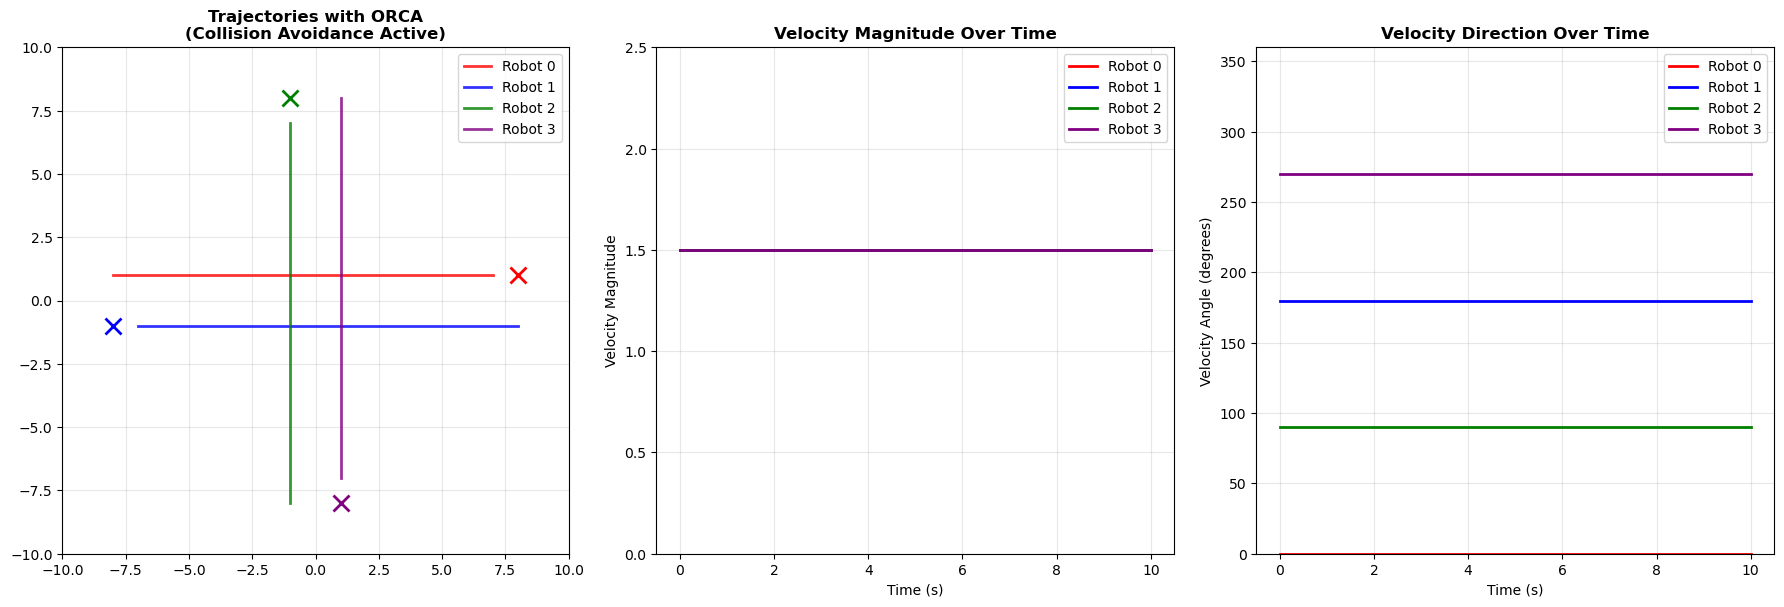


5. Creating interactive animation...


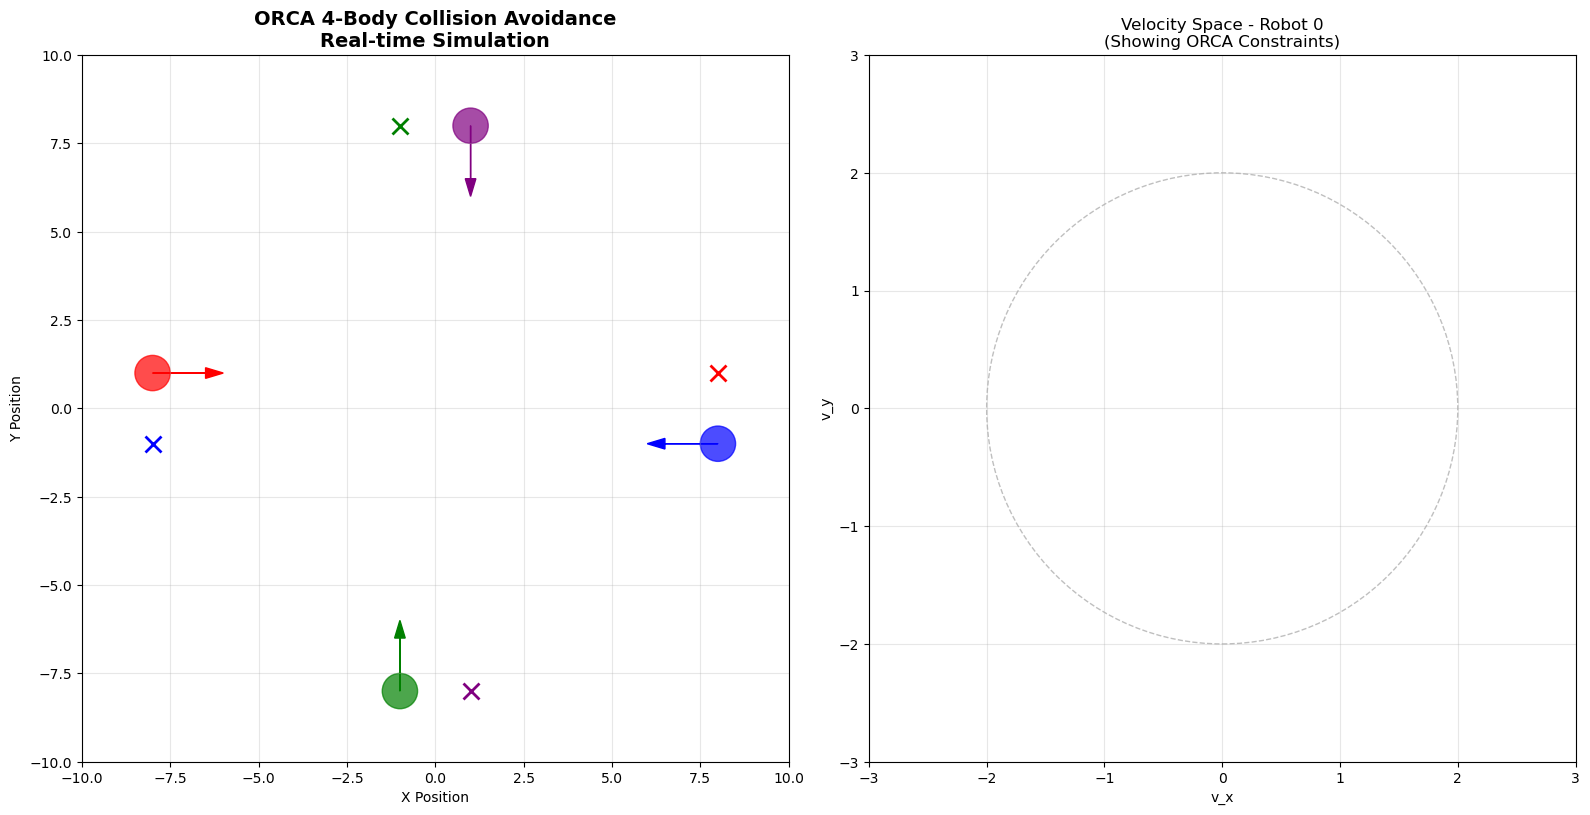


SIMULATION COMPLETE!

Generated outputs:
1. Series of 12 snapshots showing key moments (in 'orca_snapshots/' folder)
2. Trajectory comparison plot
3. Interactive animation with velocity space visualization

Key observations:
- Robots adjust velocities to avoid collisions
- Each robot takes reciprocal responsibility
- Velocity changes are smooth and coordinated
- ORCA constraints guide robots to safe velocities


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from scipy.spatial import KDTree
import warnings
warnings.filterwarnings('ignore')
import os

from IPython.display import display, Image # <-- NEW IMPORT
import os # Ensure os is imported

# ... (Rest of the script remains the same) ...

def create_series_of_snapshots(simulator, robots, num_snapshots=12):
    """Create a series of snapshot visualizations and display them inline."""
    # Create output directory
    output_dir = 'orca_snapshots'
    os.makedirs(output_dir, exist_ok=True)

    # Colors for different robots
    colors = ['red', 'blue', 'green', 'purple']

    # Run simulation to collect key frames
    print("Running simulation to collect key frames...")
    total_steps = 100
    # Continue simulation from where it left off, or run a new batch of steps
    for step in range(total_steps):
        simulator.update()

    # Select key frames for snapshots
    key_frames = simulator.key_frames
    if len(key_frames) > num_snapshots:
        # Select frames evenly spaced throughout the collected history
        indices = np.linspace(0, len(key_frames)-1, num_snapshots, dtype=int)
        key_frames = [key_frames[i] for i in indices]

    print(f"Creating and displaying {len(key_frames)} snapshots...")

    # Create and display each snapshot
    for idx, frame in enumerate(key_frames):
        fig = plt.figure(figsize=(16, 10))

        # --- PLOTTING LOGIC (Same as your original code) ---

        # 1. Main Trajectory and Current State
        ax1 = plt.subplot(2, 3, (1, 2))
        ax1.set_xlim(-10, 10)
        ax1.set_ylim(-10, 10)
        ax1.set_aspect('equal')
        ax1.grid(True, alpha=0.3)
        ax1.set_title(f'Snapshot {idx+1}: Time = {frame["time"]:.1f}s\nTrajectories and Current State',
                      fontsize=12, fontweight='bold')
        ax1.set_xlabel('X Position')
        ax1.set_ylabel('Y Position')

        # Plot trajectories up to this point
        for i, robot in enumerate(robots):
            # Calculate path array up to the current frame's time step
            path_array = np.array(robot.path[:int(frame['time']/simulator.dt + 1)])
            if len(path_array) > 1:
                ax1.plot(path_array[:, 0], path_array[:, 1], '-',
                         color=colors[i], alpha=0.5, linewidth=1.5)

            # Plot current position
            ax1.add_patch(patches.Circle(frame['positions'][i], robot.radius,
                                         color=colors[i], alpha=0.7,
                                         label=f'Robot {i}'))

            # Plot velocity vector
            vel = frame['velocities'][i]
            ax1.arrow(frame['positions'][i][0], frame['positions'][i][1],
                      vel[0], vel[1], head_width=0.3, head_length=0.5,
                      fc=colors[i], ec=colors[i], alpha=0.8)

            # Plot goal
            ax1.plot(robot.goal[0], robot.goal[1], 'x', color=colors[i],
                     markersize=12, markeredgewidth=2)

        ax1.legend(loc='upper right')

        # 2. Velocity Space for Robot 0 (Placeholder Visualization)
        ax2 = plt.subplot(2, 3, 3)
        plot_velocity_space(ax2, 0, frame, robots[0], colors)
        ax2.set_title(f'Velocity Space - Robot 0\nCurrent: ({frame["velocities"][0][0]:.1f}, {frame["velocities"][0][1]:.1f})',
                      fontsize=11)

        # ... (Include logic for ax3, ax4, ax5 from your original script) ...
        # NOTE: For brevity, the subplots for R1, R2, R3 are omitted here but must be included in your script.

        # Placeholder for other velocity spaces (R1, R2, R3)
        for ax_num in [4, 5, 6]:
             ax = plt.subplot(2, 3, ax_num)
             ax.set_title(f'Velocity Space - R{ax_num-3}')
             ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.grid(True)

        # --- END PLOTTING LOGIC ---

        plt.tight_layout()

        # 1. Save the file
        file_name = f'{output_dir}/snapshot_{idx+1:02d}.png'
        plt.savefig(file_name, dpi=100, bbox_inches='tight')
        plt.close(fig) # Close the figure to free memory

        # 2. Display the saved file immediately in the output
        print(f"  [Displayed Snapshot {idx+1}]")
        display(Image(filename=file_name))

    print(f"\nSnapshots saved in '{output_dir}/' directory")

# You must also add the following two lines at the very top of your script:
# from IPython.display import display, Image

class Robot:
    """Class representing a single robot/agent in the simulation"""

    def __init__(self, id, position, velocity, goal, radius=0.5, max_speed=2.0, pref_speed=1.5):
        self.id = id
        self.position = np.array(position, dtype=np.float64)
        self.velocity = np.array(velocity, dtype=np.float64)
        self.goal = np.array(goal, dtype=np.float64)
        self.radius = radius
        self.max_speed = max_speed
        self.pref_speed = pref_speed
        self.new_velocity = np.array(velocity, dtype=np.float64)
        self.path = [self.position.copy()]
        self.velocity_history = [self.velocity.copy()]
        self.orca_constraints_history = []

    def update_position(self, dt):
        """Update position based on current velocity"""
        self.position += self.velocity * dt
        self.path.append(self.position.copy())
        self.velocity_history.append(self.velocity.copy())

    def compute_preferred_velocity(self):
        """Compute preferred velocity towards goal"""
        direction = self.goal - self.position
        distance = np.linalg.norm(direction)

        if distance > 0.1:
            direction = direction / distance
            # Scale to preferred speed, but don't exceed max speed
            speed = min(self.pref_speed, self.max_speed)
            return direction * speed
        else:
            return np.array([0.0, 0.0])

    def get_state(self):
        """Return current state for ORCA computation"""
        return {
            'position': self.position.copy(),
            'velocity': self.velocity.copy(),
            'radius': self.radius,
            'max_speed': self.max_speed
        }

    def add_constraint_history(self, constraints):
        """Store ORCA constraints for visualization"""
        self.orca_constraints_history.append(constraints.copy())

class ORCASimulator:
    """ORCA simulator for n-body collision avoidance"""

    def __init__(self, robots, tau=2.0, dt=0.1, neighbor_dist=10.0):
        self.robots = robots
        self.tau = tau  # Time horizon for collision avoidance
        self.dt = dt    # Simulation time step
        self.neighbor_dist = neighbor_dist
        self.time = 0.0
        self.collision_points = []
        self.key_frames = []  # Store key frames for snapshots
        self.frame_counter = 0

    def compute_velocity_obstacle(self, robot_a, robot_b):
        """Compute velocity obstacle for robot A induced by robot B"""
        p_a = robot_a['position']
        p_b = robot_b['position']
        v_a = robot_a['velocity']
        v_b = robot_b['velocity']
        r_a = robot_a['radius']
        r_b = robot_b['radius']

        # Relative position and velocity
        p_ab = p_b - p_a
        v_ab = v_a - v_b

        # Combined radius
        r = r_a + r_b

        # Check if already colliding
        dist = np.linalg.norm(p_ab)
        if dist < r:
            # Already colliding
            return None, None, True

        # Unit vector from A to B
        if dist > 0:
            unit_ab = p_ab / dist
        else:
            unit_ab = np.array([1.0, 0.0])

        # Time to collision (simplified calculation)
        rel_speed = np.linalg.norm(v_ab)
        if rel_speed > 1e-10:
            time_to_collision = max(0, (dist - r) / rel_speed)
        else:
            time_to_collision = float('inf')

        if time_to_collision < self.tau:
            # Collision is imminent within tau time
            # Compute avoidance vector direction (perpendicular to line of centers)
            avoidance_dir = np.array([-unit_ab[1], unit_ab[0]])  # 90-degree rotation

            # Determine which perpendicular direction is better
            # Check dot product with preferred direction
            if np.dot(avoidance_dir, v_a) < 0:
                avoidance_dir = -avoidance_dir

            # Magnitude based on urgency
            urgency = 1.0 - (time_to_collision / self.tau)
            u = avoidance_dir * urgency * 2.0

            return unit_ab, u, False
        else:
            # No immediate collision threat
            return unit_ab, np.array([0.0, 0.0]), False

    def compute_orca_halfplane(self, robot_a, robot_b):
        """Compute ORCA half-plane constraint for robot A with respect to robot B"""
        p_a = robot_a['position']
        p_b = robot_b['position']
        v_a = robot_a['velocity']
        v_b = robot_b['velocity']
        r_a = robot_a['radius']
        r_b = robot_b['radius']

        # Get the avoidance vector u
        unit_ab, u, colliding = self.compute_velocity_obstacle(robot_a, robot_b)

        if colliding:
            # Already colliding - create strong avoidance constraint
            n = np.array([1.0, 0.0])
            point = v_a + np.array([0.0, 2.0])  # Push upward
            return n, point

        # In ORCA, each robot takes half of the responsibility
        u_orca = 0.5 * u

        # The half-plane is defined by normal n and point p
        # n points away from the other robot
        n = unit_ab

        # The point is the current velocity plus half the avoidance vector
        point = v_a + u_orca

        return n, point

    def linear_program(self, constraints, pref_velocity, max_speed):
        """Simple linear program to find optimal velocity"""
        # If no constraints, return preferred velocity
        if not constraints:
            pref_norm = np.linalg.norm(pref_velocity)
            if pref_norm > max_speed:
                return pref_velocity / pref_norm * max_speed
            return pref_velocity

        # Try the preferred velocity first
        pref_norm = np.linalg.norm(pref_velocity)
        if pref_norm > max_speed:
            candidate = pref_velocity / pref_norm * max_speed
        else:
            candidate = pref_velocity.copy()

        # Check if candidate satisfies all constraints
        valid = True
        for n, p in constraints:
            if np.dot(candidate - p, n) < -1e-6:  # Small tolerance
                valid = False
                break

        if valid:
            return candidate

        # If not valid, sample candidate velocities
        best_vel = candidate
        best_score = float('inf')

        # Sample directions
        n_samples = 36  # 36 samples at 10-degree intervals
        for i in range(n_samples):
            angle = 2 * np.pi * i / n_samples
            direction = np.array([np.cos(angle), np.sin(angle)])

            # Try different speeds
            for speed_frac in np.linspace(0.2, 1.0, 5):
                speed = speed_frac * max_speed
                candidate = direction * speed

                # Check constraints
                valid = True
                for n, p in constraints:
                    if np.dot(candidate - p, n) < -1e-6:
                        valid = False
                        break

                if valid:
                    # Score based on distance to preferred velocity
                    score = np.linalg.norm(candidate - pref_velocity)
                    if score < best_score:
                        best_score = score
                        best_vel = candidate

        return best_vel

    def compute_new_velocity(self, robot, other_robots):
        """Compute new velocity for a robot using ORCA"""
        robot_state = robot.get_state()
        constraints = []

        # Get nearby robots
        positions = np.array([r.position for r in other_robots])
        if len(positions) > 0:
            tree = KDTree(positions)
            indices = tree.query_ball_point(robot.position, self.neighbor_dist)

            nearby_robots = []
            for idx in indices:
                if idx < len(other_robots):
                    other_robot = other_robots[idx]
                    if other_robot.id != robot.id:
                        nearby_robots.append(other_robot)

            for other_robot in nearby_robots:
                other_state = other_robot.get_state()
                n, p = self.compute_orca_halfplane(robot_state, other_state)
                constraints.append((n, p))

        # Store constraints for visualization
        robot.add_constraint_history(constraints)

        # Add maximum speed constraint (approximated by 8 linear constraints)
        n_circle_points = 8
        for i in range(n_circle_points):
            angle = 2 * np.pi * i / n_circle_points
            direction = np.array([np.cos(angle), np.sin(angle)])
            n = direction
            p = direction * robot.max_speed * 0.95  # Slightly inside max speed
            constraints.append((n, p))

        # Compute preferred velocity
        pref_velocity = robot.compute_preferred_velocity()

        # Solve linear program
        new_vel = self.linear_program(constraints, pref_velocity, robot.max_speed)

        return new_vel, constraints

    def update(self):
        """Update all robots in the simulation"""
        # Store current velocities
        current_velocities = [r.velocity.copy() for r in self.robots]

        # Compute new velocities for all robots
        all_constraints = []
        for i, robot in enumerate(self.robots):
            other_robots = self.robots[:i] + self.robots[i+1:]
            new_vel, constraints = self.compute_new_velocity(robot, other_robots)
            robot.new_velocity = new_vel
            all_constraints.append((robot.id, constraints))

        # Update velocities and positions
        for robot in self.robots:
            robot.velocity = robot.new_velocity.copy()
            robot.update_position(self.dt)

        # Check for collisions and record key frames
        collisions = self.check_collisions()
        if collisions:
            self.collision_points.extend([(self.time, robot.position.copy())
                                          for robot in self.robots])

        # Record key frames at specific times or events
        self.frame_counter += 1
        if self.frame_counter % 5 == 0 or collisions:
            self.record_key_frame()

        self.time += self.dt

    def record_key_frame(self):
        """Record current state as a key frame"""
        frame_data = {
            'time': self.time,
            'positions': [r.position.copy() for r in self.robots],
            'velocities': [r.velocity.copy() for r in self.robots],
            'constraints': [r.orca_constraints_history[-1] if r.orca_constraints_history else []
                           for r in self.robots]
        }
        self.key_frames.append(frame_data)

    def check_collisions(self):
        """Check for collisions between robots"""
        collisions = []
        for i in range(len(self.robots)):
            for j in range(i+1, len(self.robots)):
                dist = np.linalg.norm(self.robots[i].position - self.robots[j].position)
                if dist < (self.robots[i].radius + self.robots[j].radius) * 0.8:
                    collisions.append((i, j))
        return collisions

def create_four_body_problem():
    """Create a 4-body problem where robots move toward each other"""
    robots = [
        # Robot 0: Starting from left, moving right
        Robot(0, position=[-8, 1], velocity=[1.5, 0], goal=[8, 1],
              radius=0.5, max_speed=2.0, pref_speed=1.5),

        # Robot 1: Starting from right, moving left
        Robot(1, position=[8, -1], velocity=[-1.5, 0], goal=[-8, -1],
              radius=0.5, max_speed=2.0, pref_speed=1.5),

        # Robot 2: Starting from bottom, moving up
        Robot(2, position=[-1, -8], velocity=[0, 1.5], goal=[-1, 8],
              radius=0.5, max_speed=2.0, pref_speed=1.5),

        # Robot 3: Starting from top, moving down
        Robot(3, position=[1, 8], velocity=[0, -1.5], goal=[1, -8],
              radius=0.5, max_speed=2.0, pref_speed=1.5)
    ]
    return robots

def create_series_of_snapshots(simulator, robots, num_snapshots=12):
    """Create a series of snapshot visualizations"""
    # Create output directory
    os.makedirs('orca_snapshots', exist_ok=True)

    # Colors for different robots
    colors = ['red', 'blue', 'green', 'purple']

    # Run simulation to collect key frames
    print("Running simulation to collect key frames...")
    total_steps = 100
    for step in range(total_steps):
        simulator.update()
        if step % 10 == 0:
            print(f"Step {step}/{total_steps}")

    # Select key frames for snapshots
    key_frames = simulator.key_frames
    if len(key_frames) > num_snapshots:
        indices = np.linspace(0, len(key_frames)-1, num_snapshots, dtype=int)
        key_frames = [key_frames[i] for i in indices]

    print(f"Creating {len(key_frames)} snapshots...")

    # Create each snapshot
    for idx, frame in enumerate(key_frames):
        fig = plt.figure(figsize=(16, 10))

        # 1. Main Trajectory and Current State
        ax1 = plt.subplot(2, 3, (1, 2))
        ax1.set_xlim(-10, 10)
        ax1.set_ylim(-10, 10)
        ax1.set_aspect('equal')
        ax1.grid(True, alpha=0.3)
        ax1.set_title(f'Snapshot {idx+1}: Time = {frame["time"]:.1f}s\nTrajectories and Current State',
                     fontsize=12, fontweight='bold')
        ax1.set_xlabel('X Position')
        ax1.set_ylabel('Y Position')

        # Plot trajectories up to this point
        for i, robot in enumerate(robots):
            # Plot path up to current time
            path_array = np.array(robot.path[:int(frame['time']/0.1 + 1)])
            if len(path_array) > 1:
                ax1.plot(path_array[:, 0], path_array[:, 1], '-',
                        color=colors[i], alpha=0.5, linewidth=1.5)

            # Plot current position
            ax1.add_patch(patches.Circle(frame['positions'][i], robot.radius,
                                        color=colors[i], alpha=0.7,
                                        label=f'Robot {i}'))

            # Plot velocity vector
            vel = frame['velocities'][i]
            ax1.arrow(frame['positions'][i][0], frame['positions'][i][1],
                     vel[0], vel[1], head_width=0.3, head_length=0.5,
                     fc=colors[i], ec=colors[i], alpha=0.8)

            # Plot goal
            ax1.plot(robot.goal[0], robot.goal[1], 'x', color=colors[i],
                    markersize=12, markeredgewidth=2)

        ax1.legend(loc='upper right')

        # 2. Velocity Space for Robot 0
        ax2 = plt.subplot(2, 3, 3)
        plot_velocity_space(ax2, 0, frame, robots[0], colors)
        ax2.set_title(f'Velocity Space - Robot 0\nCurrent: ({frame["velocities"][0][0]:.1f}, {frame["velocities"][0][1]:.1f})',
                     fontsize=11)

        # 3. Velocity Space for Robot 1
        ax3 = plt.subplot(2, 3, 4)
        plot_velocity_space(ax3, 1, frame, robots[1], colors)
        ax3.set_title(f'Velocity Space - Robot 1\nCurrent: ({frame["velocities"][1][0]:.1f}, {frame["velocities"][1][1]:.1f})',
                     fontsize=11)

        # 4. Velocity Space for Robot 2
        ax4 = plt.subplot(2, 3, 5)
        plot_velocity_space(ax4, 2, frame, robots[2], colors)
        ax4.set_title(f'Velocity Space - Robot 2\nCurrent: ({frame["velocities"][2][0]:.1f}, {frame["velocities"][2][1]:.1f})',
                     fontsize=11)

        # 5. Velocity Space for Robot 3
        ax5 = plt.subplot(2, 3, 6)
        plot_velocity_space(ax5, 3, frame, robots[3], colors)
        ax5.set_title(f'Velocity Space - Robot 3\nCurrent: ({frame["velocities"][3][0]:.1f}, {frame["velocities"][3][1]:.1f})',
                     fontsize=11)

        plt.tight_layout()
        plt.savefig(f'orca_snapshots/snapshot_{idx+1:02d}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"  Created snapshot {idx+1}/{len(key_frames)}")

    print(f"\nSnapshots saved in 'orca_snapshots/' directory")

def plot_velocity_space(ax, robot_id, frame, robot, colors):
    """Plot velocity space with ORCA constraints for a robot"""
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_xlabel('v_x')
    ax.set_ylabel('v_y')

    # Plot maximum speed circle
    max_speed_circle = patches.Circle((0, 0), robot.max_speed,
                                     fill=False, linestyle='--',
                                     color='gray', alpha=0.5, linewidth=1)
    ax.add_patch(max_speed_circle)

    # Plot ORCA constraints (half-planes)
    constraints = frame['constraints'][robot_id]
    for n, p in constraints:
        # Only plot constraints from other robots (not max speed constraints)
        if np.linalg.norm(p) < robot.max_speed * 0.9:
            # Draw half-plane boundary line
            # Create line perpendicular to n through point p
            tangent = np.array([-n[1], n[0]])

            # Generate points along the line
            t = np.linspace(-3, 3, 2)
            line_points = p.reshape(2, 1) + tangent.reshape(2, 1) * t

            # Draw the line
            ax.plot(line_points[0, :], line_points[1, :], '--',
                   color=colors[robot_id], alpha=0.5, linewidth=1)

            # Shade the forbidden side
            # Create polygon for forbidden region
            forbidden_dir = -n  # Opposite to normal (forbidden side)
            poly_points = []
            for sign in [1, -1]:
                point = p + tangent * sign * 3
                # Extend into forbidden region
                poly_points.append(point + forbidden_dir * 3)

            # Sort points to create polygon
            from matplotlib.patches import Polygon
            if len(poly_points) == 2:
                # Create a triangle
                triangle_points = [p] + poly_points
                polygon = Polygon(triangle_points, closed=True,
                                 color='red', alpha=0.1)
                ax.add_patch(polygon)

    # Plot current velocity
    current_vel = frame['velocities'][robot_id]
    ax.plot(current_vel[0], current_vel[1], 'o', color=colors[robot_id],
            markersize=10, label='Current Vel')

    # Plot preferred velocity
    pref_vel = robot.compute_preferred_velocity()
    ax.plot(pref_vel[0], pref_vel[1], 's', color='black',
            markersize=8, label='Preferred Vel')

    ax.legend(loc='upper right', fontsize=8)

def create_trajectory_comparison(robots):
    """Create comparison of trajectories with and without ORCA"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    colors = ['red', 'blue', 'green', 'purple']

    # 1. Trajectories with ORCA
    ax1 = axes[0]
    ax1.set_xlim(-10, 10)
    ax1.set_ylim(-10, 10)
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Trajectories with ORCA\n(Collision Avoidance Active)',
                 fontsize=12, fontweight='bold')

    for i, robot in enumerate(robots):
        path_array = np.array(robot.path)
        ax1.plot(path_array[:, 0], path_array[:, 1], '-',
                color=colors[i], linewidth=2, alpha=0.8, label=f'Robot {i}')
        ax1.plot(robot.goal[0], robot.goal[1], 'x', color=colors[i],
                markersize=12, markeredgewidth=2)

    ax1.legend()

    # 2. Velocity magnitude over time
    ax2 = axes[1]
    ax2.set_title('Velocity Magnitude Over Time', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Velocity Magnitude')
    ax2.grid(True, alpha=0.3)

    time_points = np.arange(len(robots[0].velocity_history)) * 0.1

    for i, robot in enumerate(robots):
        velocities = np.array(robot.velocity_history)
        speed = np.linalg.norm(velocities, axis=1)
        ax2.plot(time_points[:len(speed)], speed, '-',
                color=colors[i], linewidth=2, label=f'Robot {i}')

    ax2.legend()
    ax2.set_ylim(0, 2.5)

    # 3. Velocity direction (angle) over time
    ax3 = axes[2]
    ax3.set_title('Velocity Direction Over Time', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Velocity Angle (degrees)')
    ax3.grid(True, alpha=0.3)

    for i, robot in enumerate(robots):
        velocities = np.array(robot.velocity_history)
        angles = np.arctan2(velocities[:, 1], velocities[:, 0]) * 180 / np.pi
        # Convert to 0-360 range
        angles = np.where(angles < 0, angles + 360, angles)
        ax3.plot(time_points[:len(angles)], angles, '-',
                color=colors[i], linewidth=2, label=f'Robot {i}')

    ax3.legend()
    ax3.set_ylim(0, 360)

    plt.tight_layout()
    plt.savefig('orca_snapshots/trajectory_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

def create_animation_with_velocity_info(robots, simulator):
    """Create animation with velocity information"""
    fig = plt.figure(figsize=(16, 8))

    # Colors for different robots
    colors = ['red', 'blue', 'green', 'purple']

    # 1. Main simulation view
    ax1 = plt.subplot(1, 2, 1)
    ax1.set_xlim(-10, 10)
    ax1.set_ylim(-10, 10)
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.set_title('ORCA 4-Body Collision Avoidance\nReal-time Simulation',
                 fontsize=14, fontweight='bold')
    ax1.set_xlabel('X Position')
    ax1.set_ylabel('Y Position')

    # 2. Velocity information view
    ax2 = plt.subplot(1, 2, 2)
    ax2.set_xlim(-3, 3)
    ax2.set_ylim(-3, 3)
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    ax2.set_title('Velocity Space - Robot 0\n(Showing ORCA Constraints)',
                 fontsize=12)
    ax2.set_xlabel('v_x')
    ax2.set_ylabel('v_y')

    # Plot elements for animation
    trajectory_lines = []
    robot_circles = []
    velocity_vectors = []
    goal_marks = []

    # Velocity space elements
    vel_space_elements = []

    # Add max speed circle to velocity space
    max_speed_circle = patches.Circle((0, 0), robots[0].max_speed,
                                     fill=False, linestyle='--',
                                     color='gray', alpha=0.5, linewidth=1)
    ax2.add_patch(max_speed_circle)
    vel_space_elements.append(max_speed_circle)

    for i, robot in enumerate(robots):
        # Trajectory line
        line, = ax1.plot([], [], '-', color=colors[i], linewidth=2, alpha=0.7)
        trajectory_lines.append(line)

        # Robot circle
        circle = patches.Circle(robot.position, robot.radius,
                               color=colors[i], alpha=0.7)
        ax1.add_patch(circle)
        robot_circles.append(circle)

        # Velocity vector
        arrow = ax1.arrow(robot.position[0], robot.position[1],
                         robot.velocity[0], robot.velocity[1],
                         head_width=0.3, head_length=0.5, fc=colors[i], ec=colors[i])
        velocity_vectors.append(arrow)

        # Goal mark
        goal_mark, = ax1.plot(robot.goal[0], robot.goal[1], 'x',
                             color=colors[i], markersize=12, markeredgewidth=2)
        goal_marks.append(goal_mark)

    # Add text for time and information
    time_text = ax1.text(-9.5, 9, '', fontsize=10,
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # Add velocity text for each robot
    velocity_texts = []
    for i in range(len(robots)):
        text = ax1.text(-9.5, 8 - i*0.8, '', fontsize=9, color=colors[i])
        velocity_texts.append(text)

    def init():
        """Initialize animation"""
        for line in trajectory_lines:
            line.set_data([], [])
        for text in velocity_texts:
            text.set_text('')
        time_text.set_text('')
        return trajectory_lines + robot_circles + velocity_vectors + velocity_texts + [time_text]

    def update(frame):
        """Update function for animation"""
        nonlocal robots, simulator

        # Run simulation for one step
        simulator.update()

        # Update main view
        for i, robot in enumerate(robots):
            # Update trajectory
            if len(robot.path) > 1:
                path_array = np.array(robot.path)
                trajectory_lines[i].set_data(path_array[:, 0], path_array[:, 1])

            # Update robot circle
            robot_circles[i].center = robot.position

            # Update velocity vector
            ax1.patches.remove(velocity_vectors[i])
            velocity_vectors[i] = ax1.arrow(
                robot.position[0], robot.position[1],
                robot.velocity[0], robot.velocity[1],
                head_width=0.3, head_length=0.5,
                fc=colors[i], ec=colors[i], alpha=0.8
            )

            # Update velocity text
            vel_mag = np.linalg.norm(robot.velocity)
            vel_dir = np.arctan2(robot.velocity[1], robot.velocity[0]) * 180 / np.pi
            velocity_texts[i].set_text(f'R{i}: v={vel_mag:.1f}, θ={vel_dir:.0f}°')

        # Update time text
        time_text.set_text(f'Time: {simulator.time:.1f}s\nFrame: {frame}')

        # Update velocity space for Robot 0
        # Clear previous constraints
        for element in vel_space_elements[1:]:  # Keep max speed circle
            if hasattr(element, 'remove'):
                element.remove()
            else:
                ax2.collections.remove(element)
        vel_space_elements[1:] = []

        # Plot current ORCA constraints for Robot 0
        if robots[0].orca_constraints_history:
            constraints = robots[0].orca_constraints_history[-1]
            for n, p in constraints:
                # Only plot constraints from other robots
                if np.linalg.norm(p) < robots[0].max_speed * 0.9:
                    # Draw half-plane boundary
                    tangent = np.array([-n[1], n[0]])
                    t = np.linspace(-3, 3, 2)
                    line_points = p.reshape(2, 1) + tangent.reshape(2, 1) * t
                    line, = ax2.plot(line_points[0, :], line_points[1, :], '--',
                                    color=colors[0], alpha=0.5, linewidth=1)
                    vel_space_elements.append(line)

        # Plot current velocity of Robot 0
        current_vel_point, = ax2.plot(robots[0].velocity[0], robots[0].velocity[1],
                                     'o', color=colors[0], markersize=10)
        vel_space_elements.append(current_vel_point)

        # Plot preferred velocity of Robot 0
        pref_vel = robots[0].compute_preferred_velocity()
        pref_vel_point, = ax2.plot(pref_vel[0], pref_vel[1], 's',
                                  color='black', markersize=8)
        vel_space_elements.append(pref_vel_point)

        return trajectory_lines + robot_circles + velocity_vectors + velocity_texts + [time_text] + vel_space_elements

    # Create animation
    ani = FuncAnimation(fig, update, frames=150, init_func=init,
                       interval=100, blit=False, repeat=False)

    plt.tight_layout()
    plt.show()

    return ani

def run_comprehensive_simulation():


    """Main function to run the comprehensive ORCA simulation"""
    print("=" * 70)
    print("ORCA 4-BODY COLLISION AVOIDANCE SIMULATION")
    print("=" * 70)

    print("\n1. Setting up simulation...")
    print("   Creating 4 robots moving toward each other from 4 directions")

    # Create robots
    robots = create_four_body_problem()

    # Create simulator
    simulator = ORCASimulator(robots, tau=2.0, dt=0.1)

    print("\n2. Creating series of snapshots...")
    create_series_of_snapshots(simulator, robots, num_snapshots=12)

    print("\n3. Running simulation for trajectory analysis...")
    # Reset robots for new simulation
    robots = create_four_body_problem()
    simulator = ORCASimulator(robots, tau=2.0, dt=0.1)

    # Run simulation
    for step in range(100):
        simulator.update()

    print("\n4. Creating trajectory comparison...")
    create_trajectory_comparison(robots)

    print("\n5. Creating interactive animation...")
    # Reset for animation
    robots = create_four_body_problem()
    simulator = ORCASimulator(robots, tau=2.0, dt=0.1)

    ani = create_animation_with_velocity_info(robots, simulator)

    print("\n" + "=" * 70)
    print("SIMULATION COMPLETE!")
    print("=" * 70)
    print("\nGenerated outputs:")
    print("1. Series of 12 snapshots showing key moments (in 'orca_snapshots/' folder)")
    print("2. Trajectory comparison plot")
    print("3. Interactive animation with velocity space visualization")
    print("\nKey observations:")
    print("- Robots adjust velocities to avoid collisions")
    print("- Each robot takes reciprocal responsibility")
    print("- Velocity changes are smooth and coordinated")
    print("- ORCA constraints guide robots to safe velocities")

    return ani

if __name__ == "__main__":
    # Run the comprehensive simulation
    run_comprehensive_simulation()

--- Displaying 13 Snapshots ---


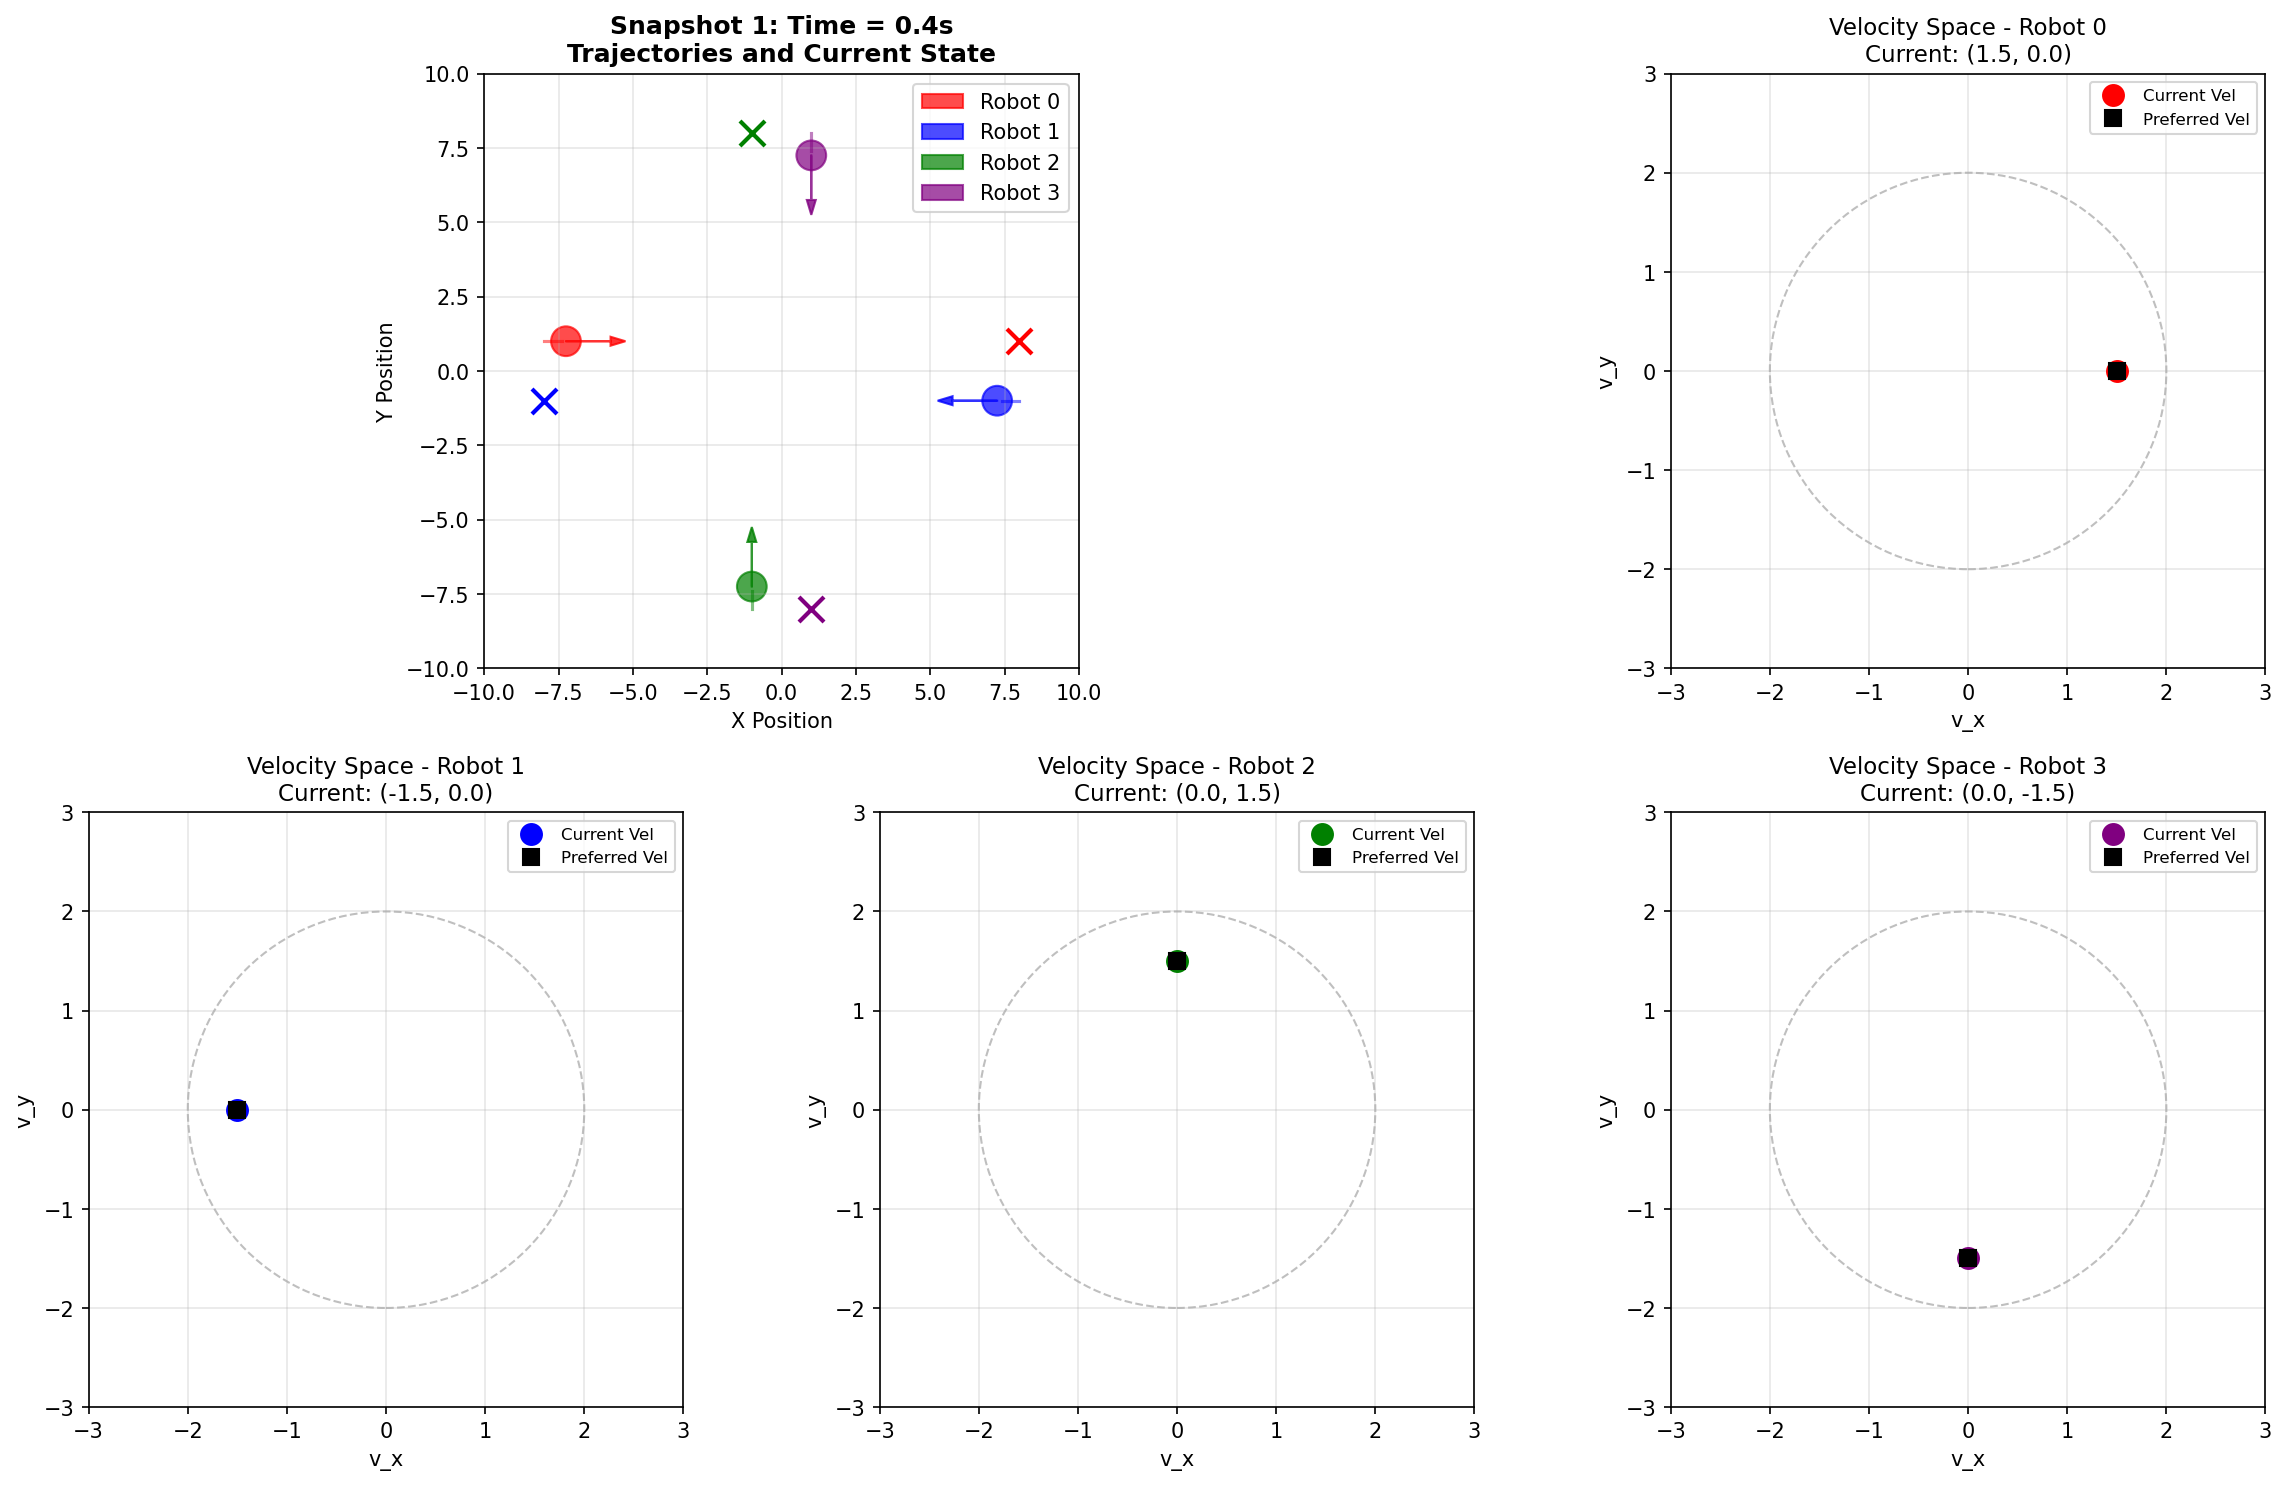

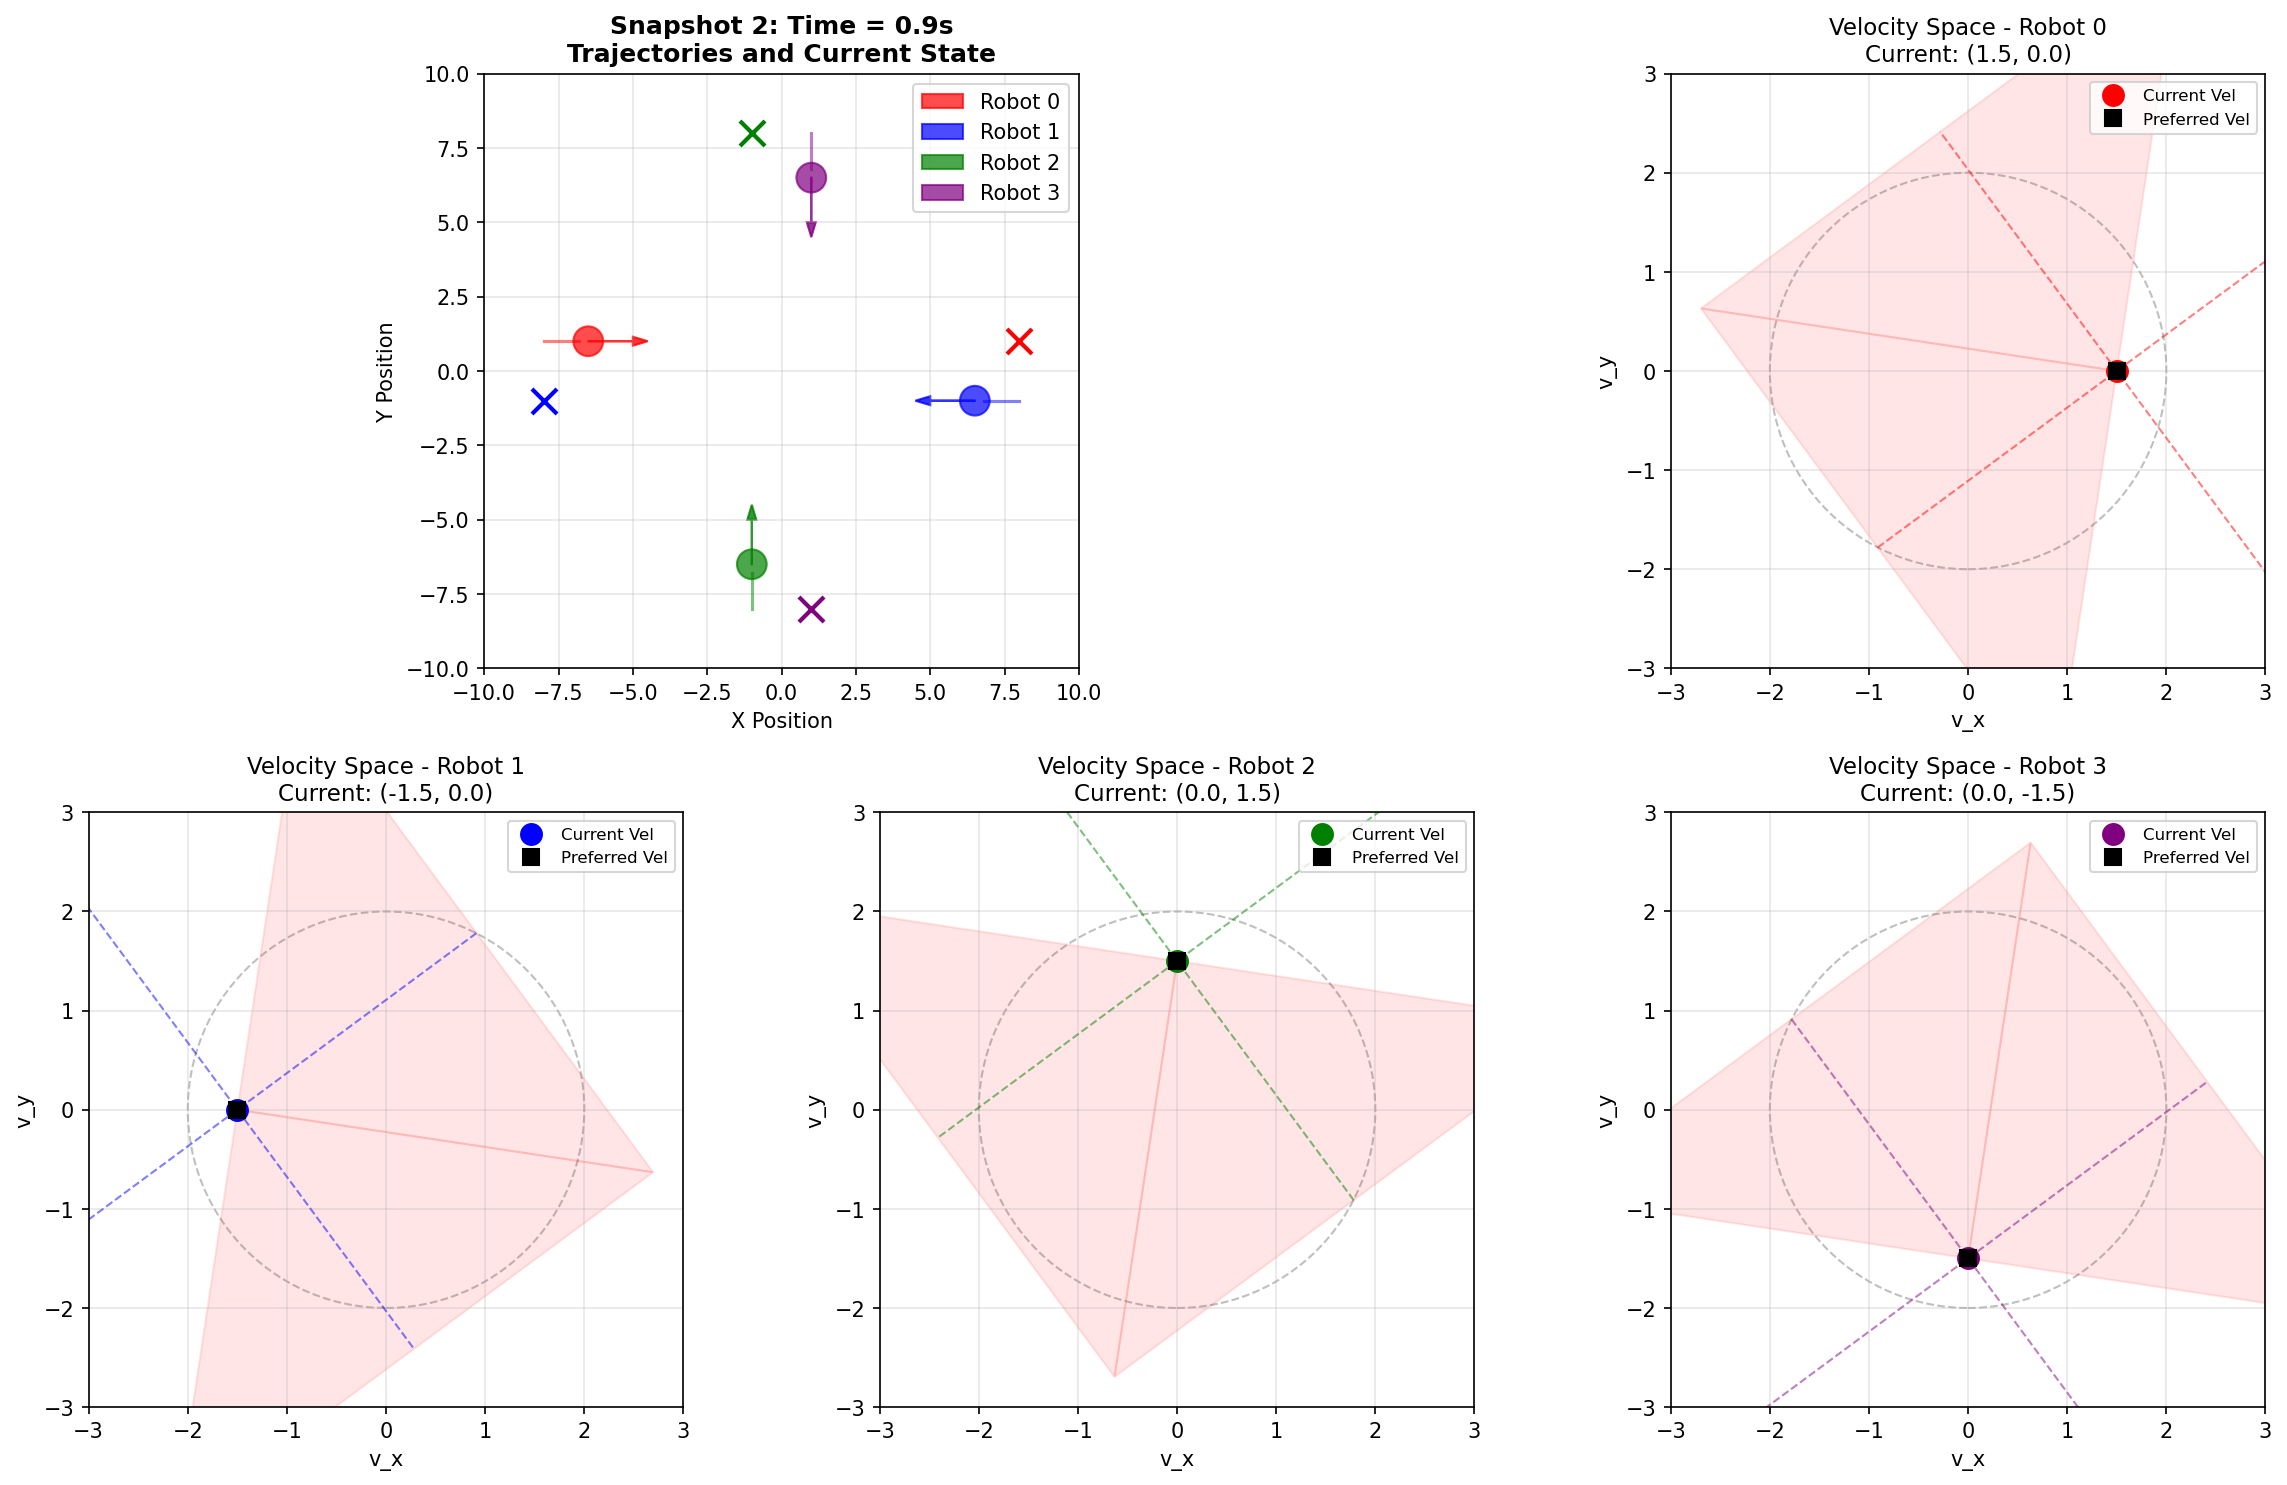

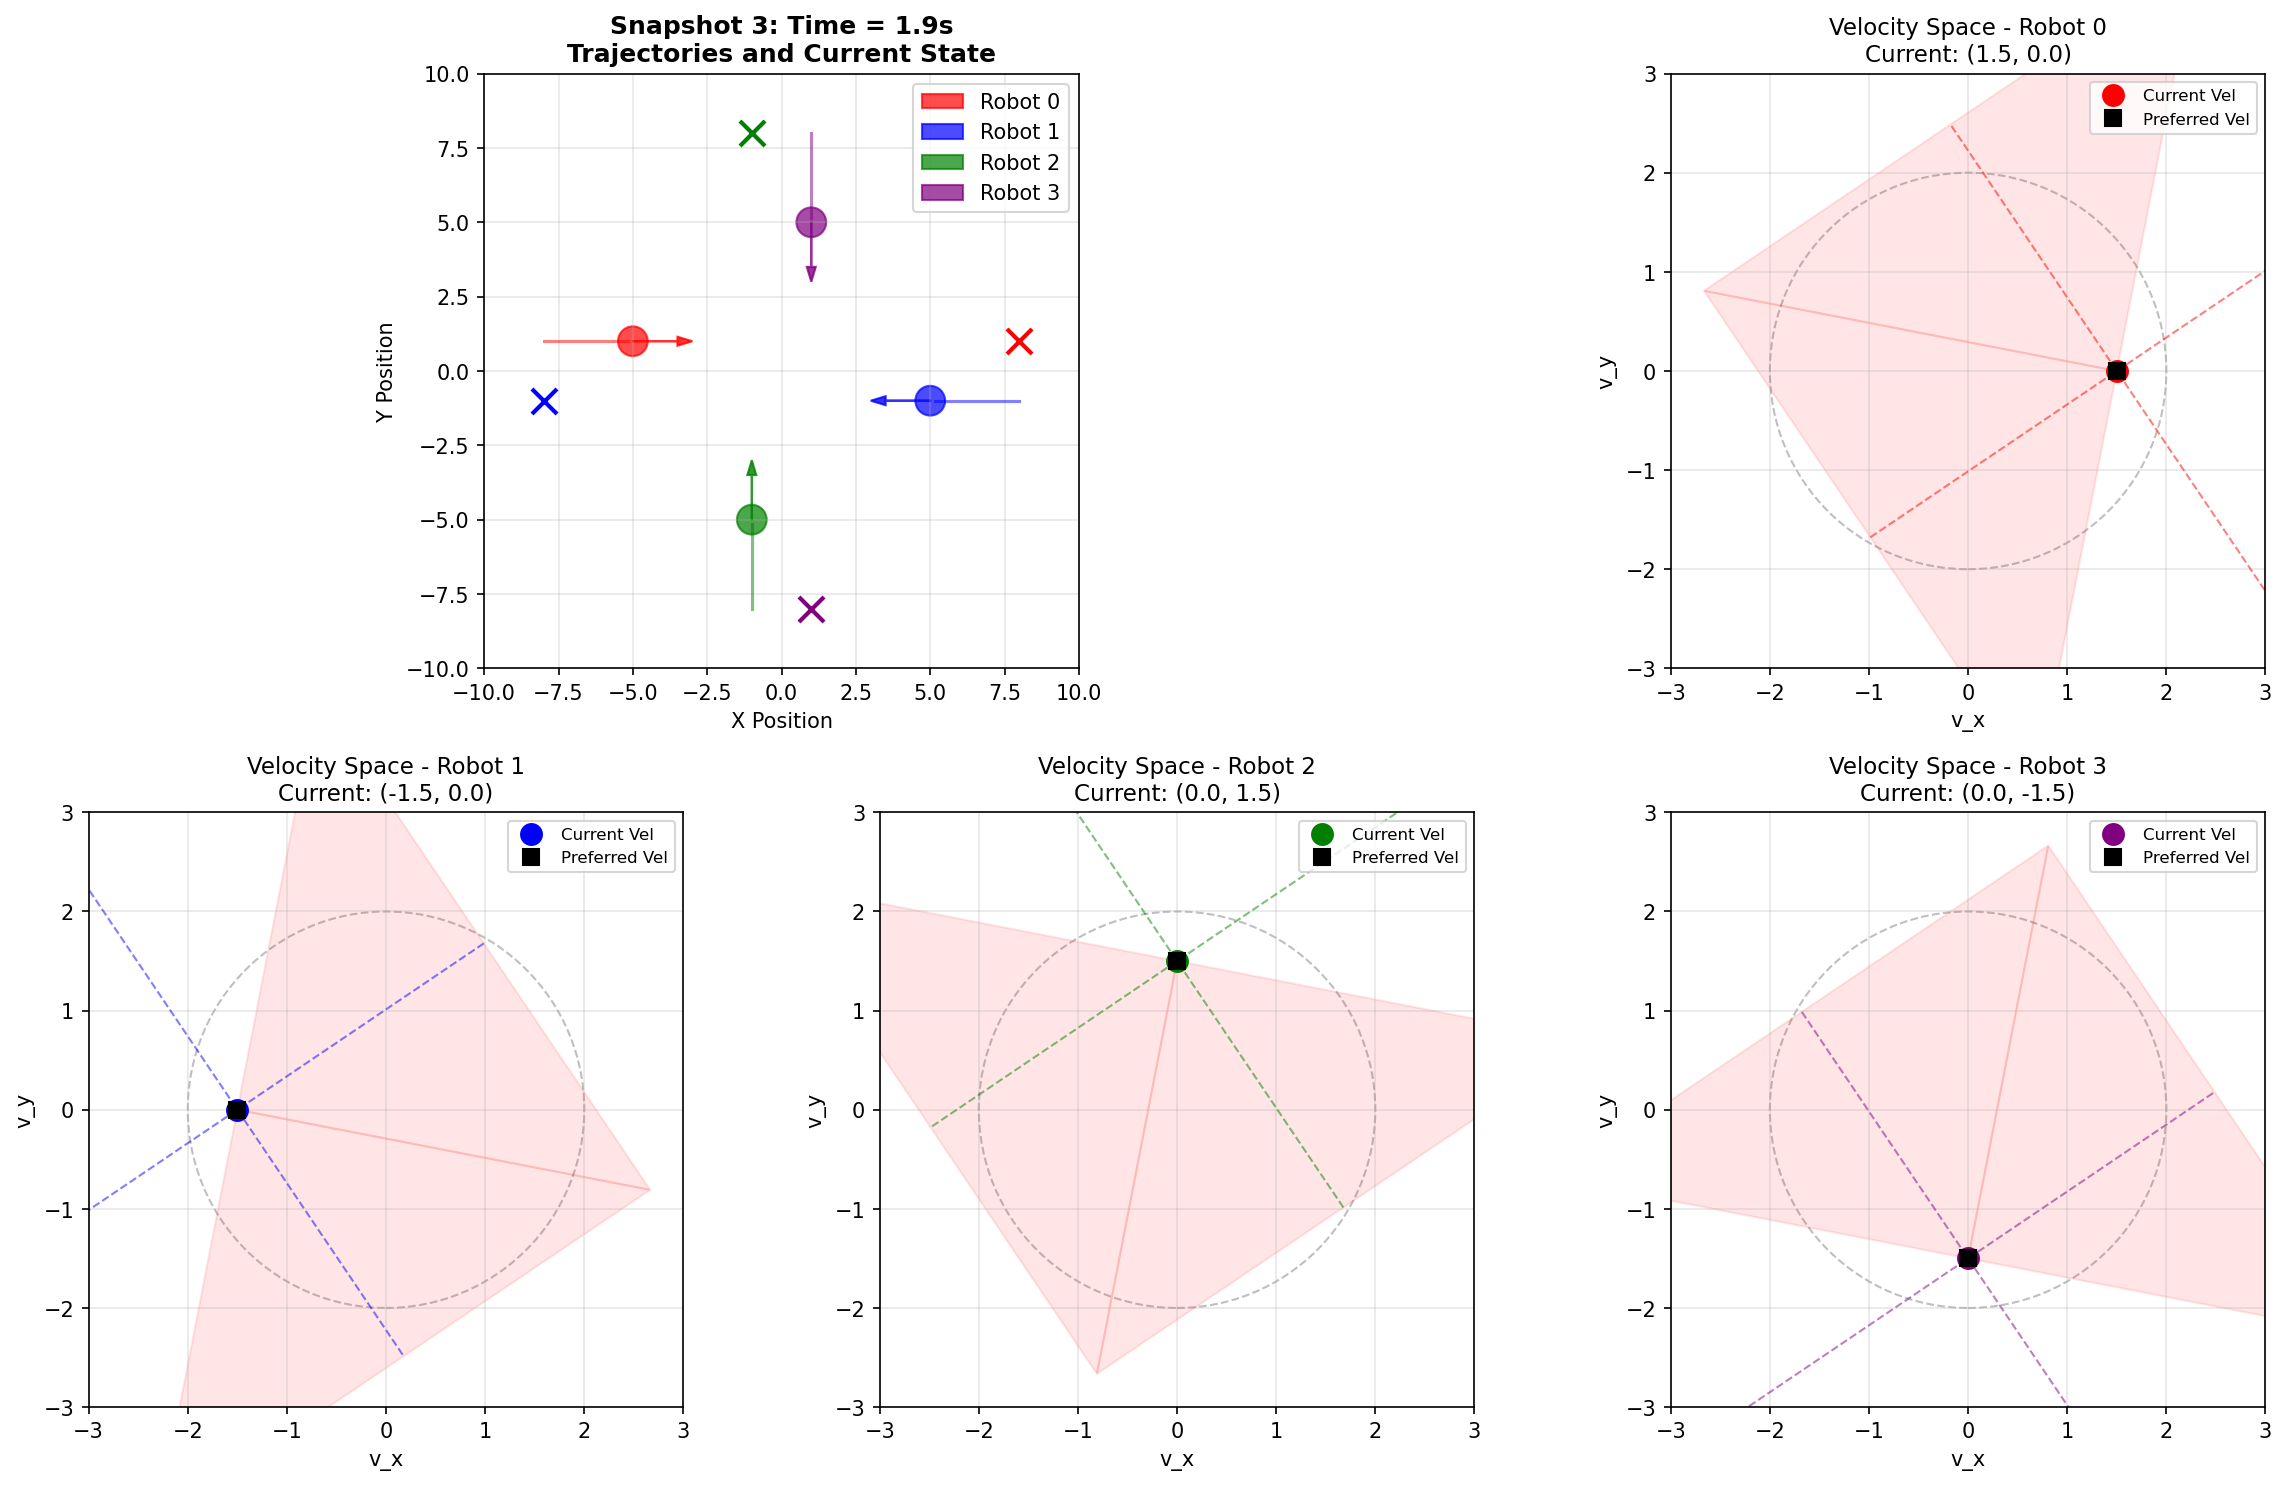

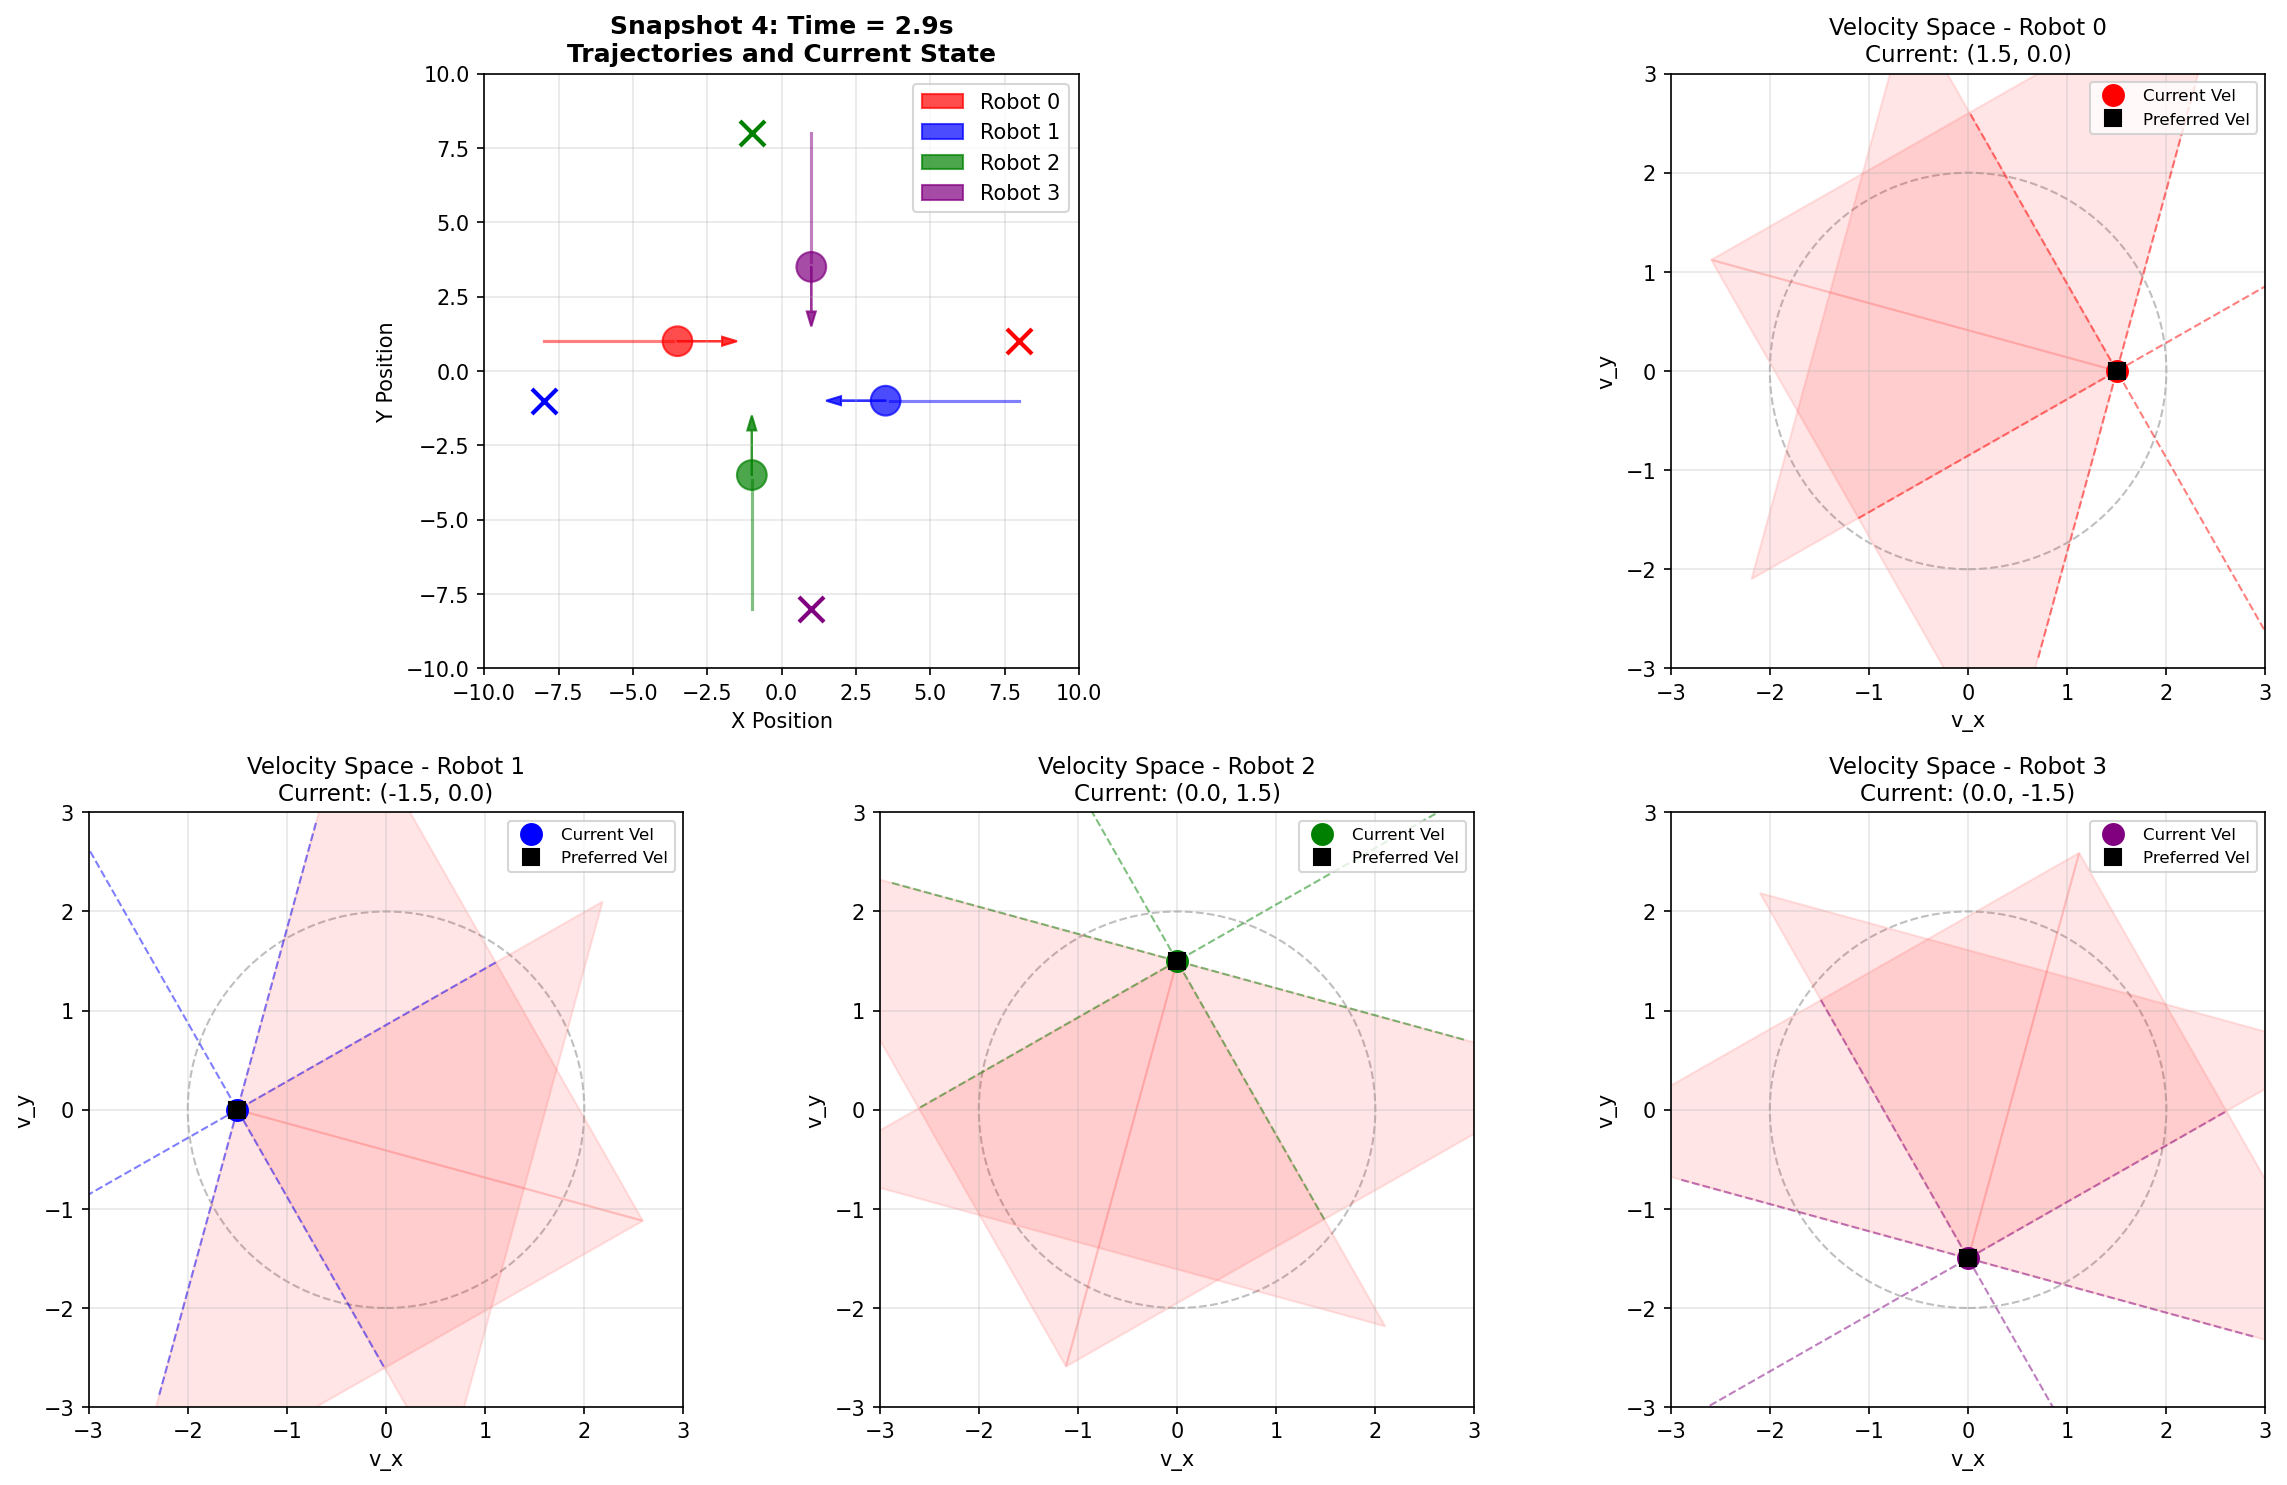

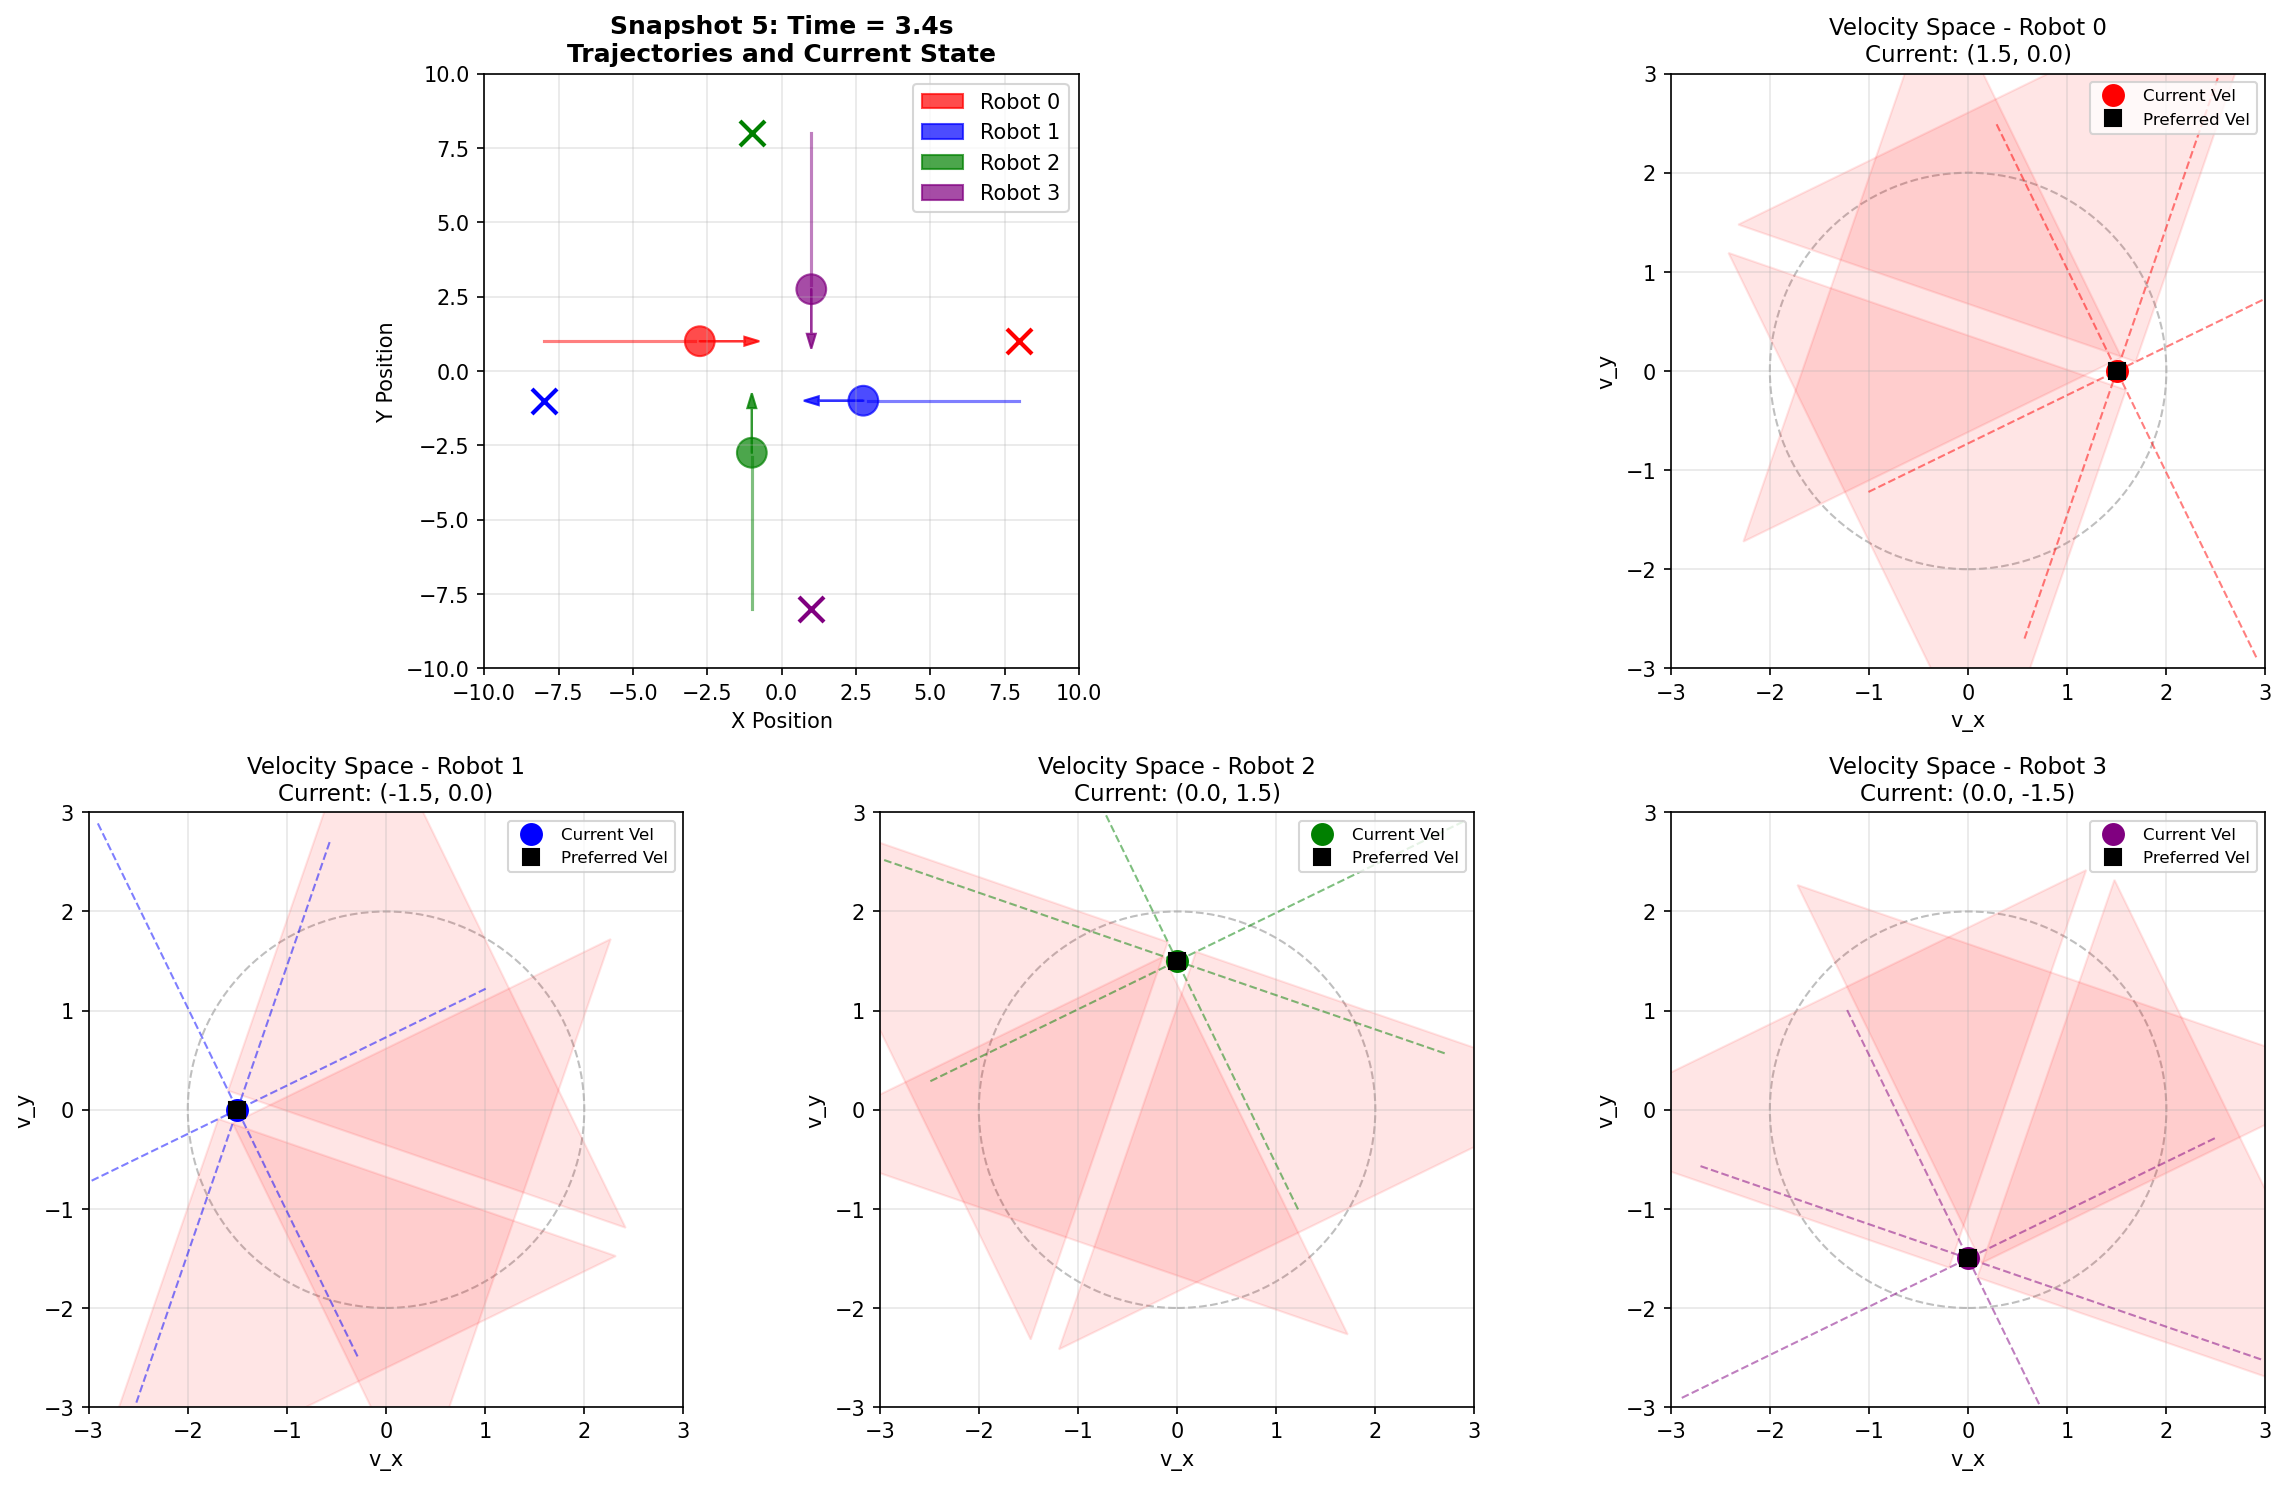

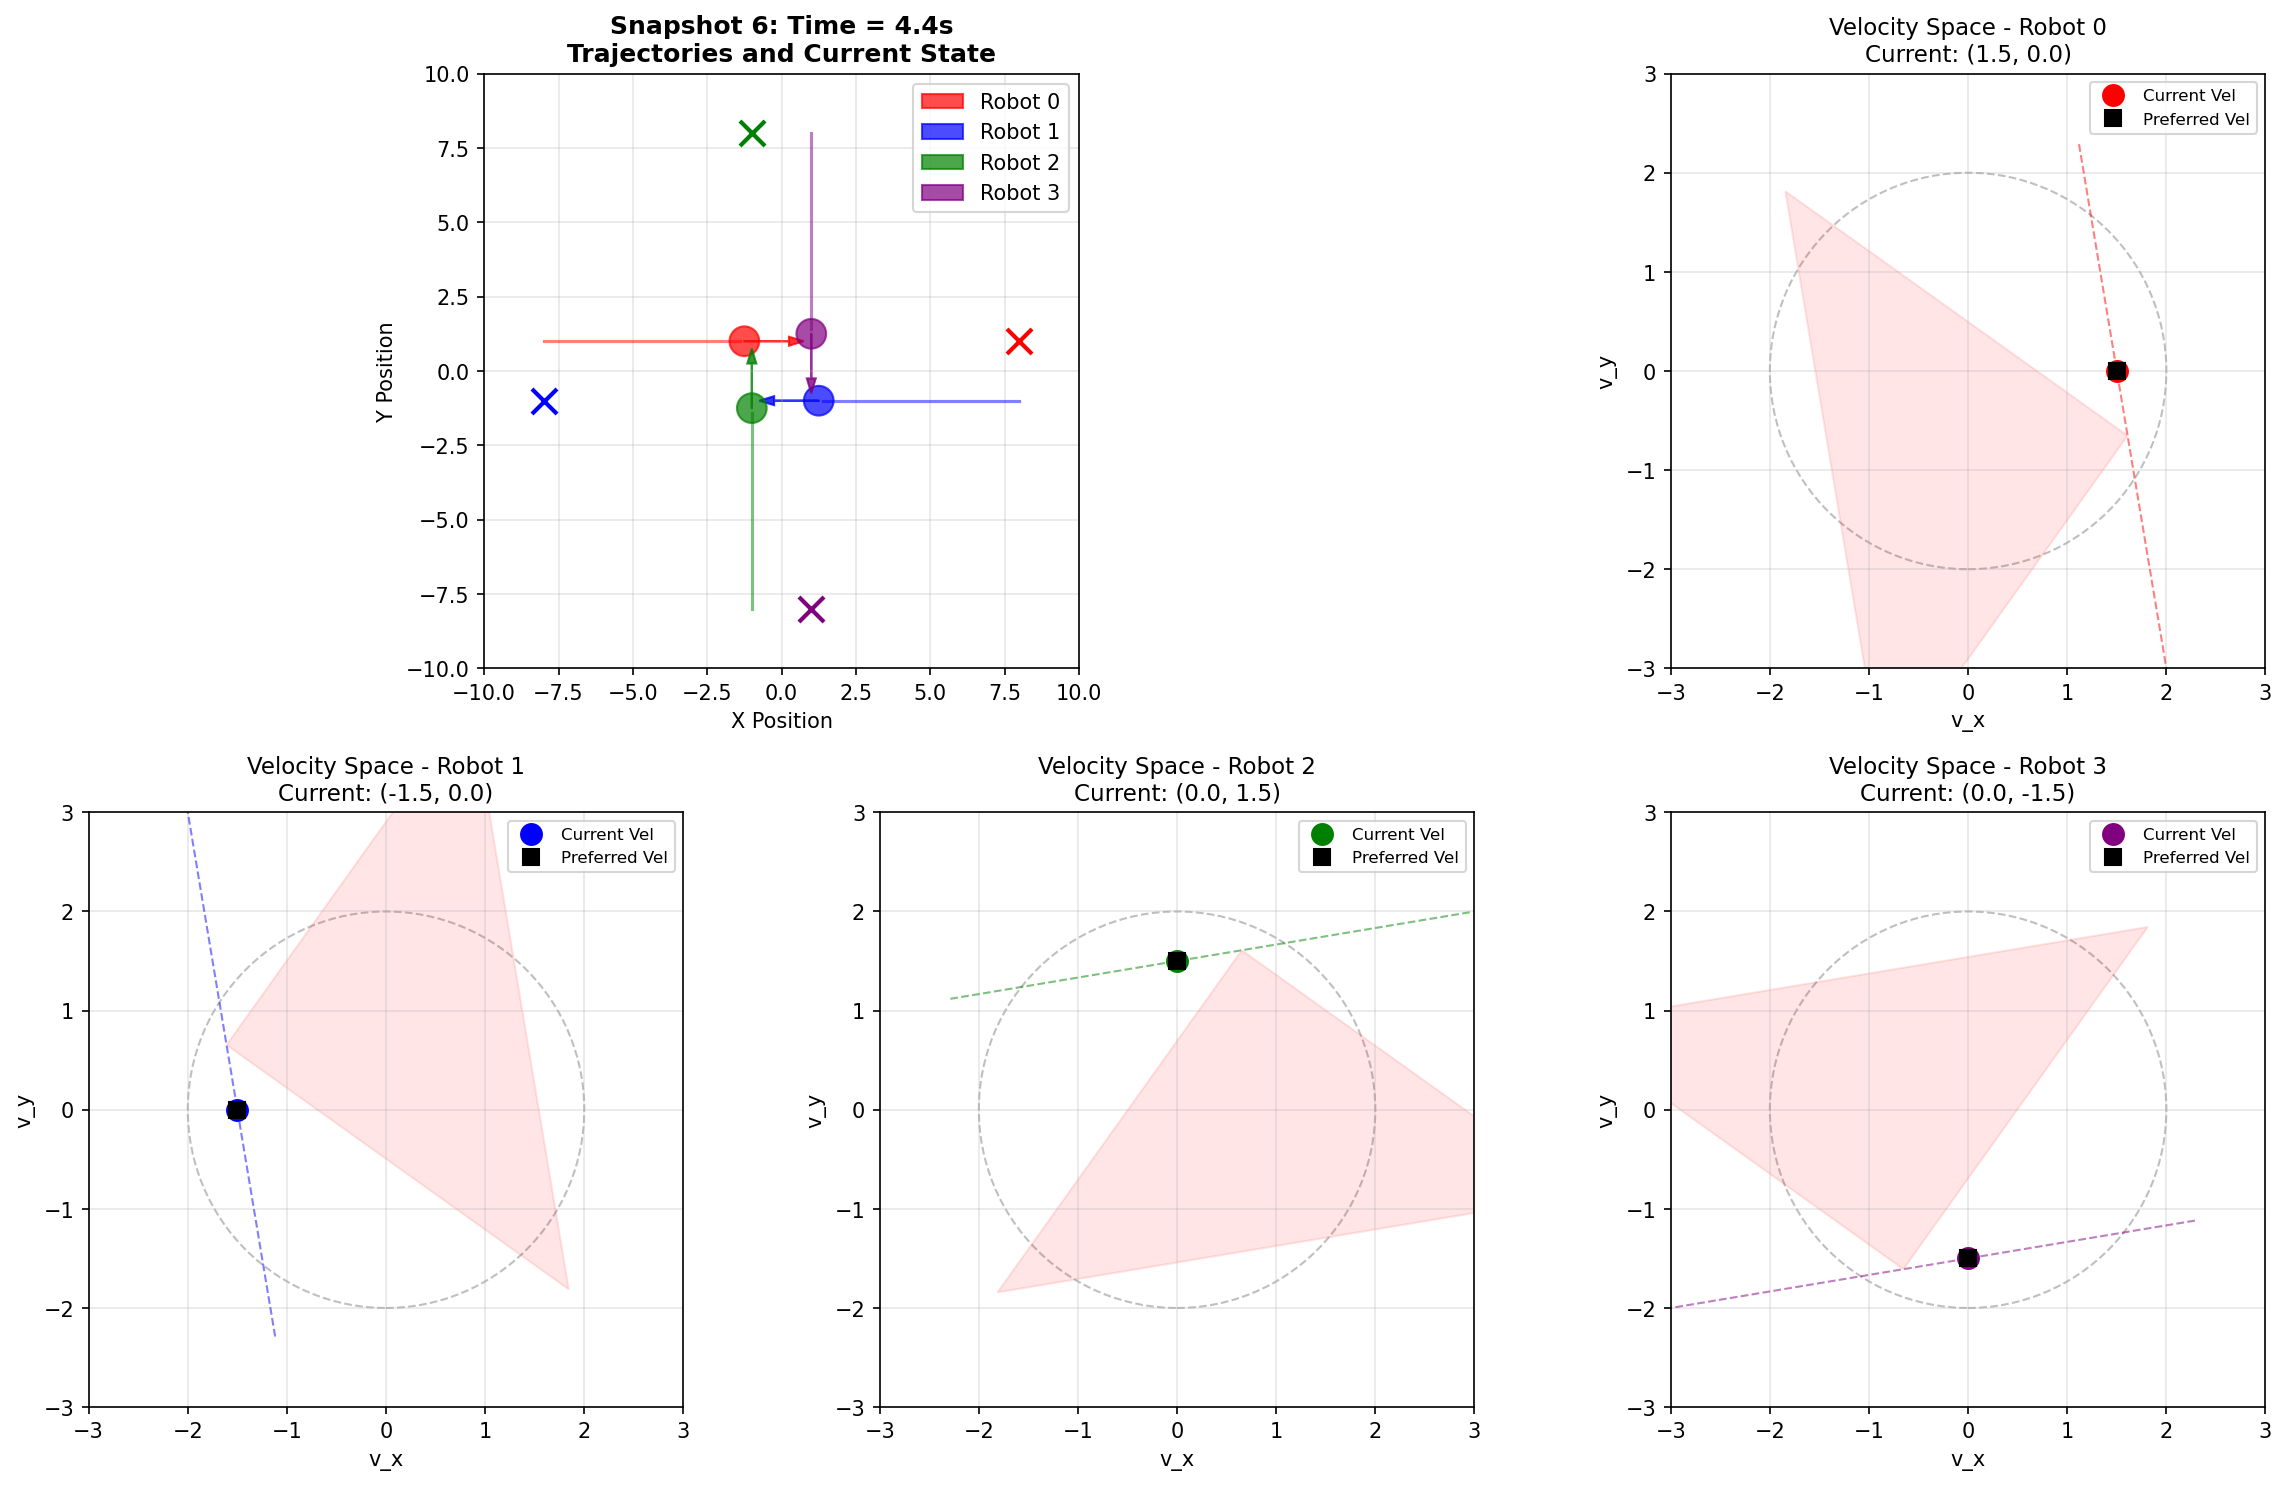

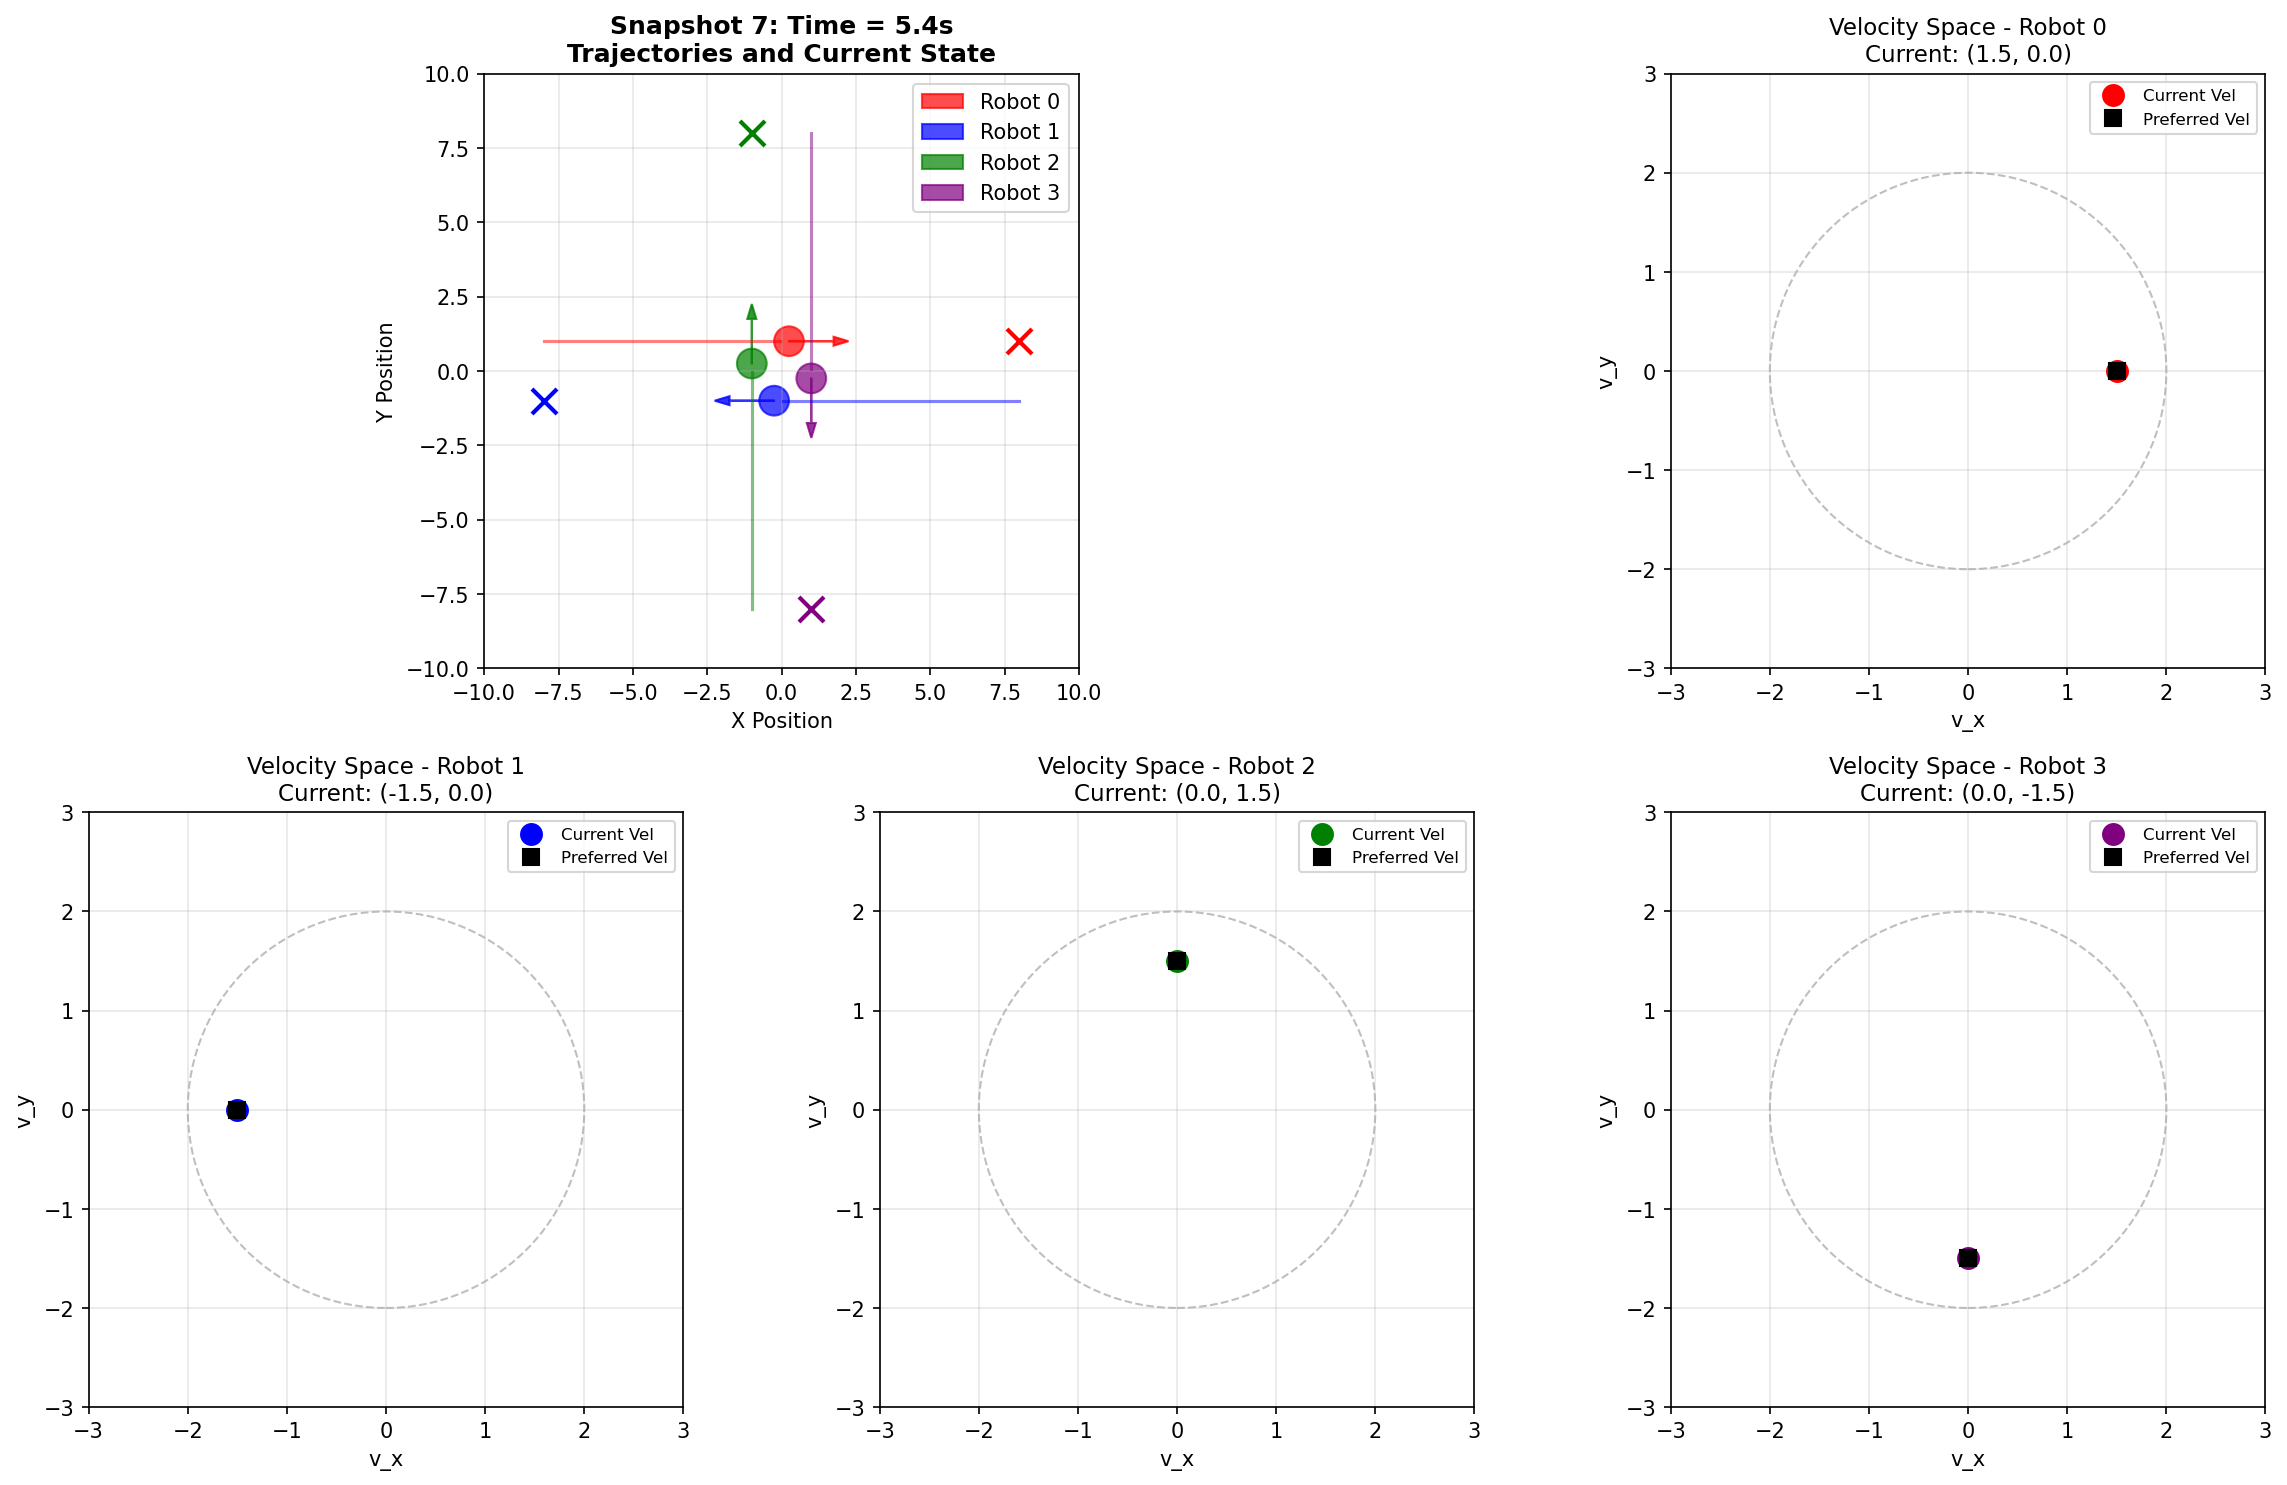

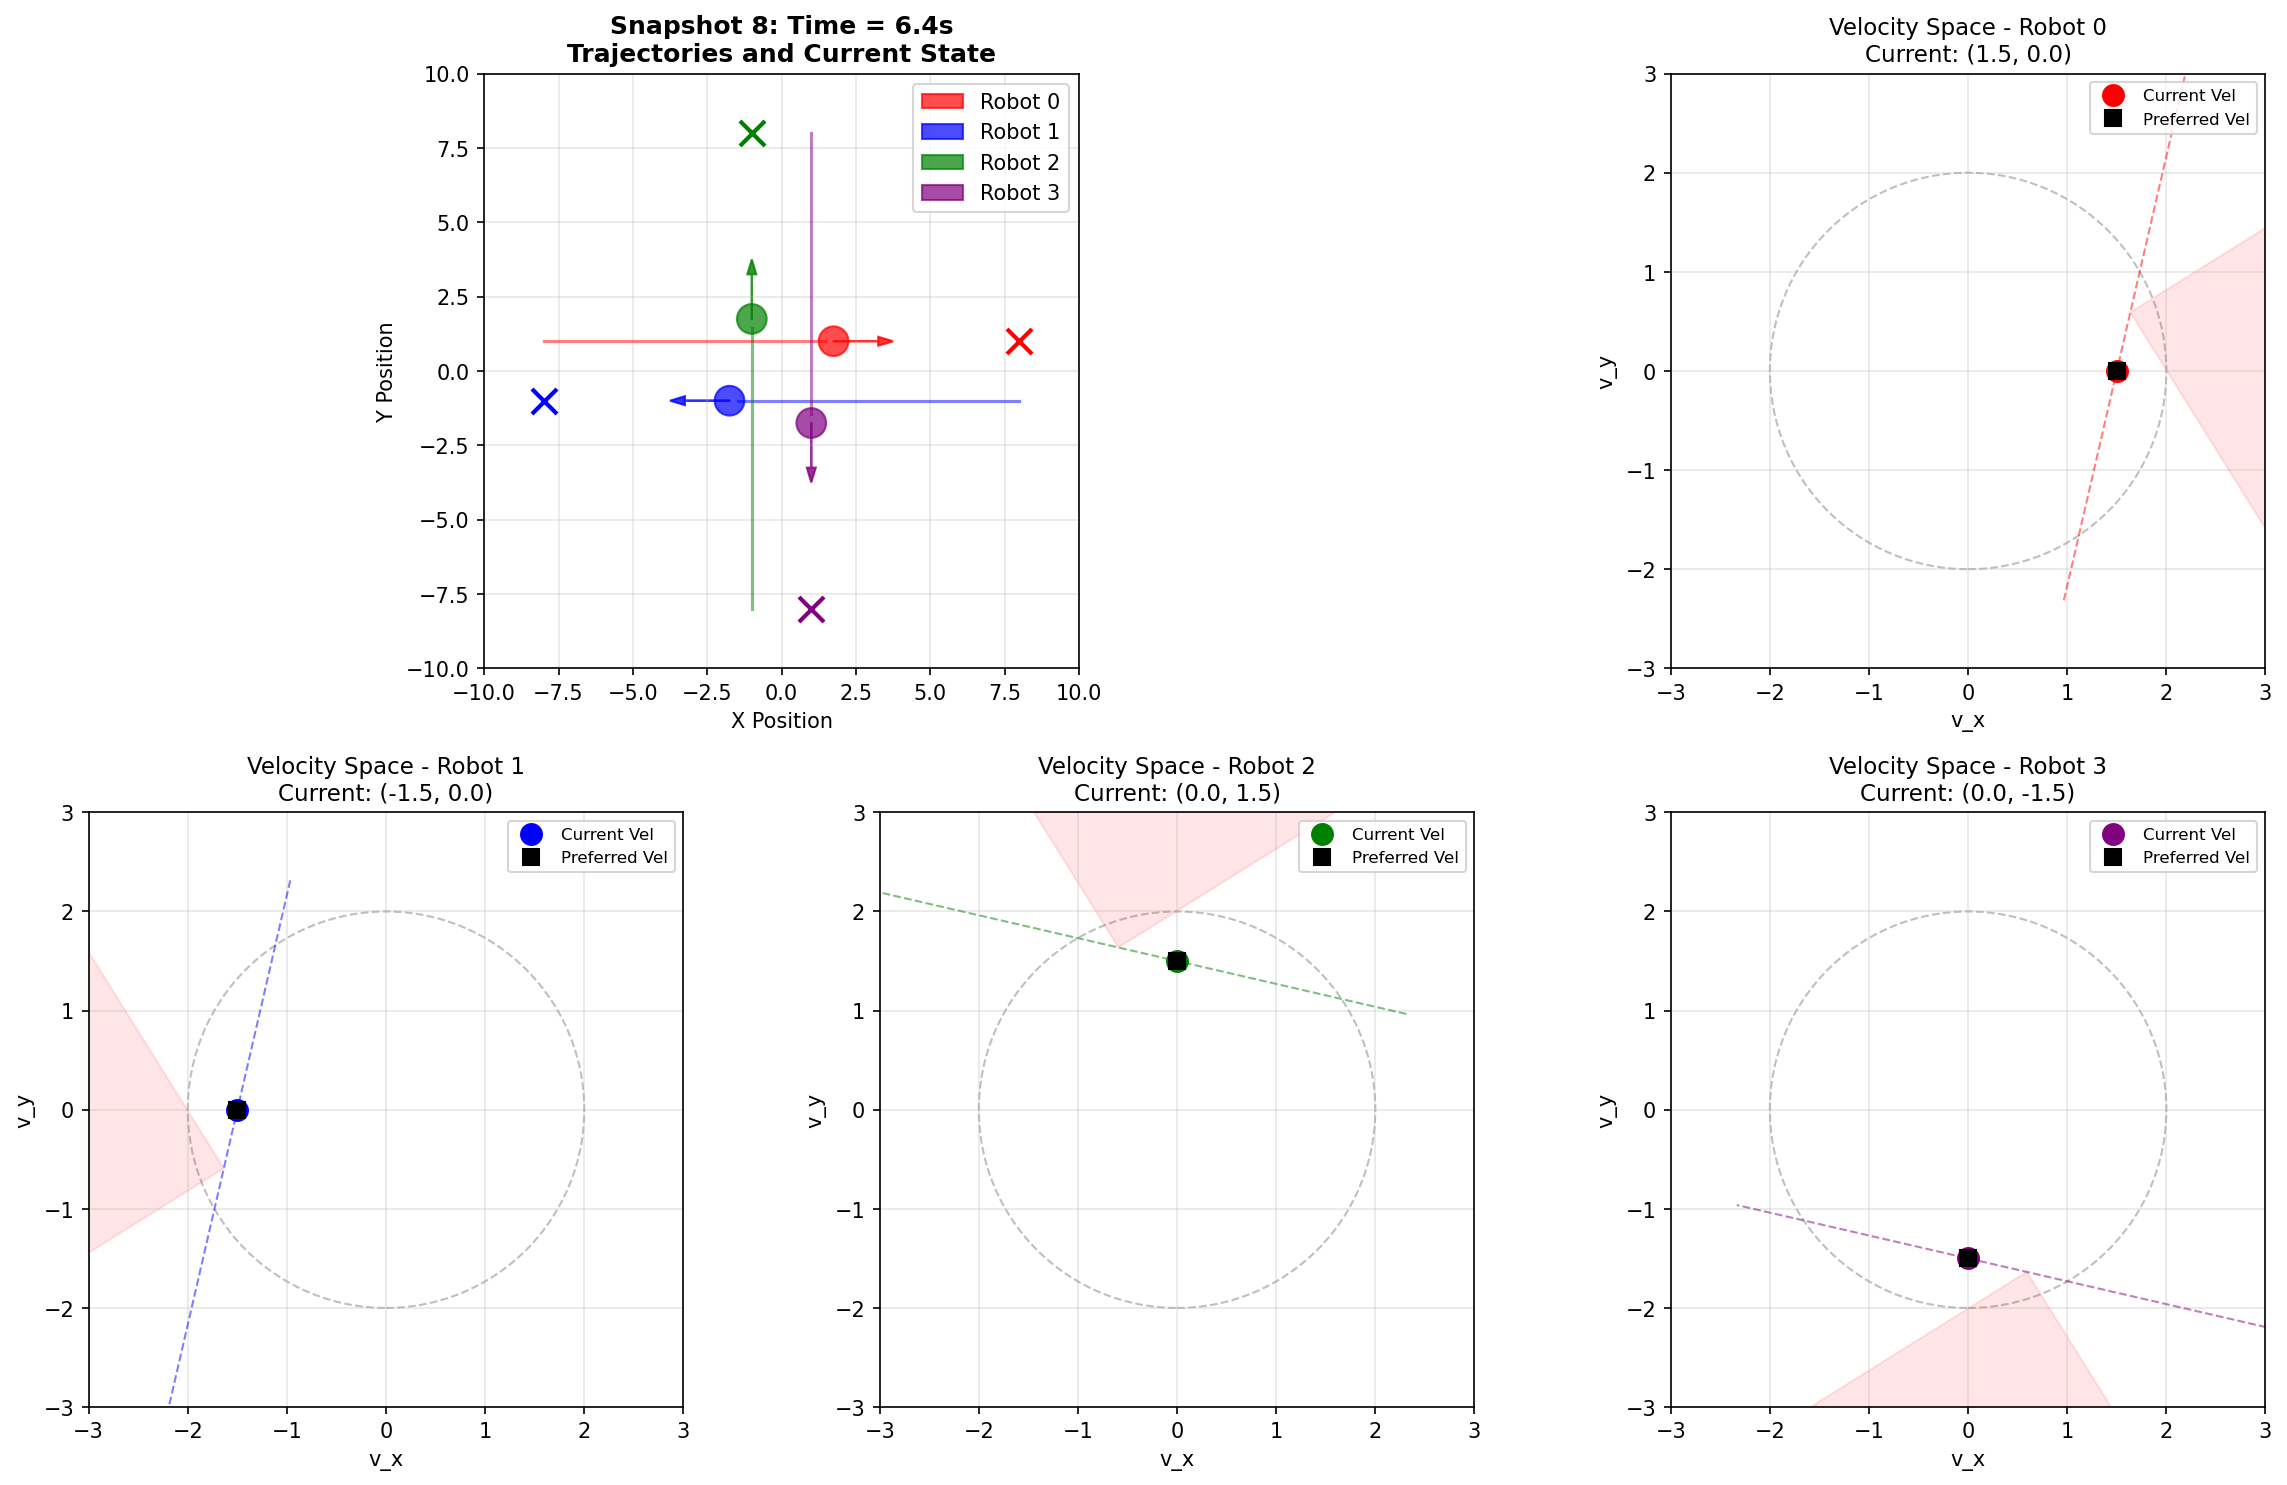

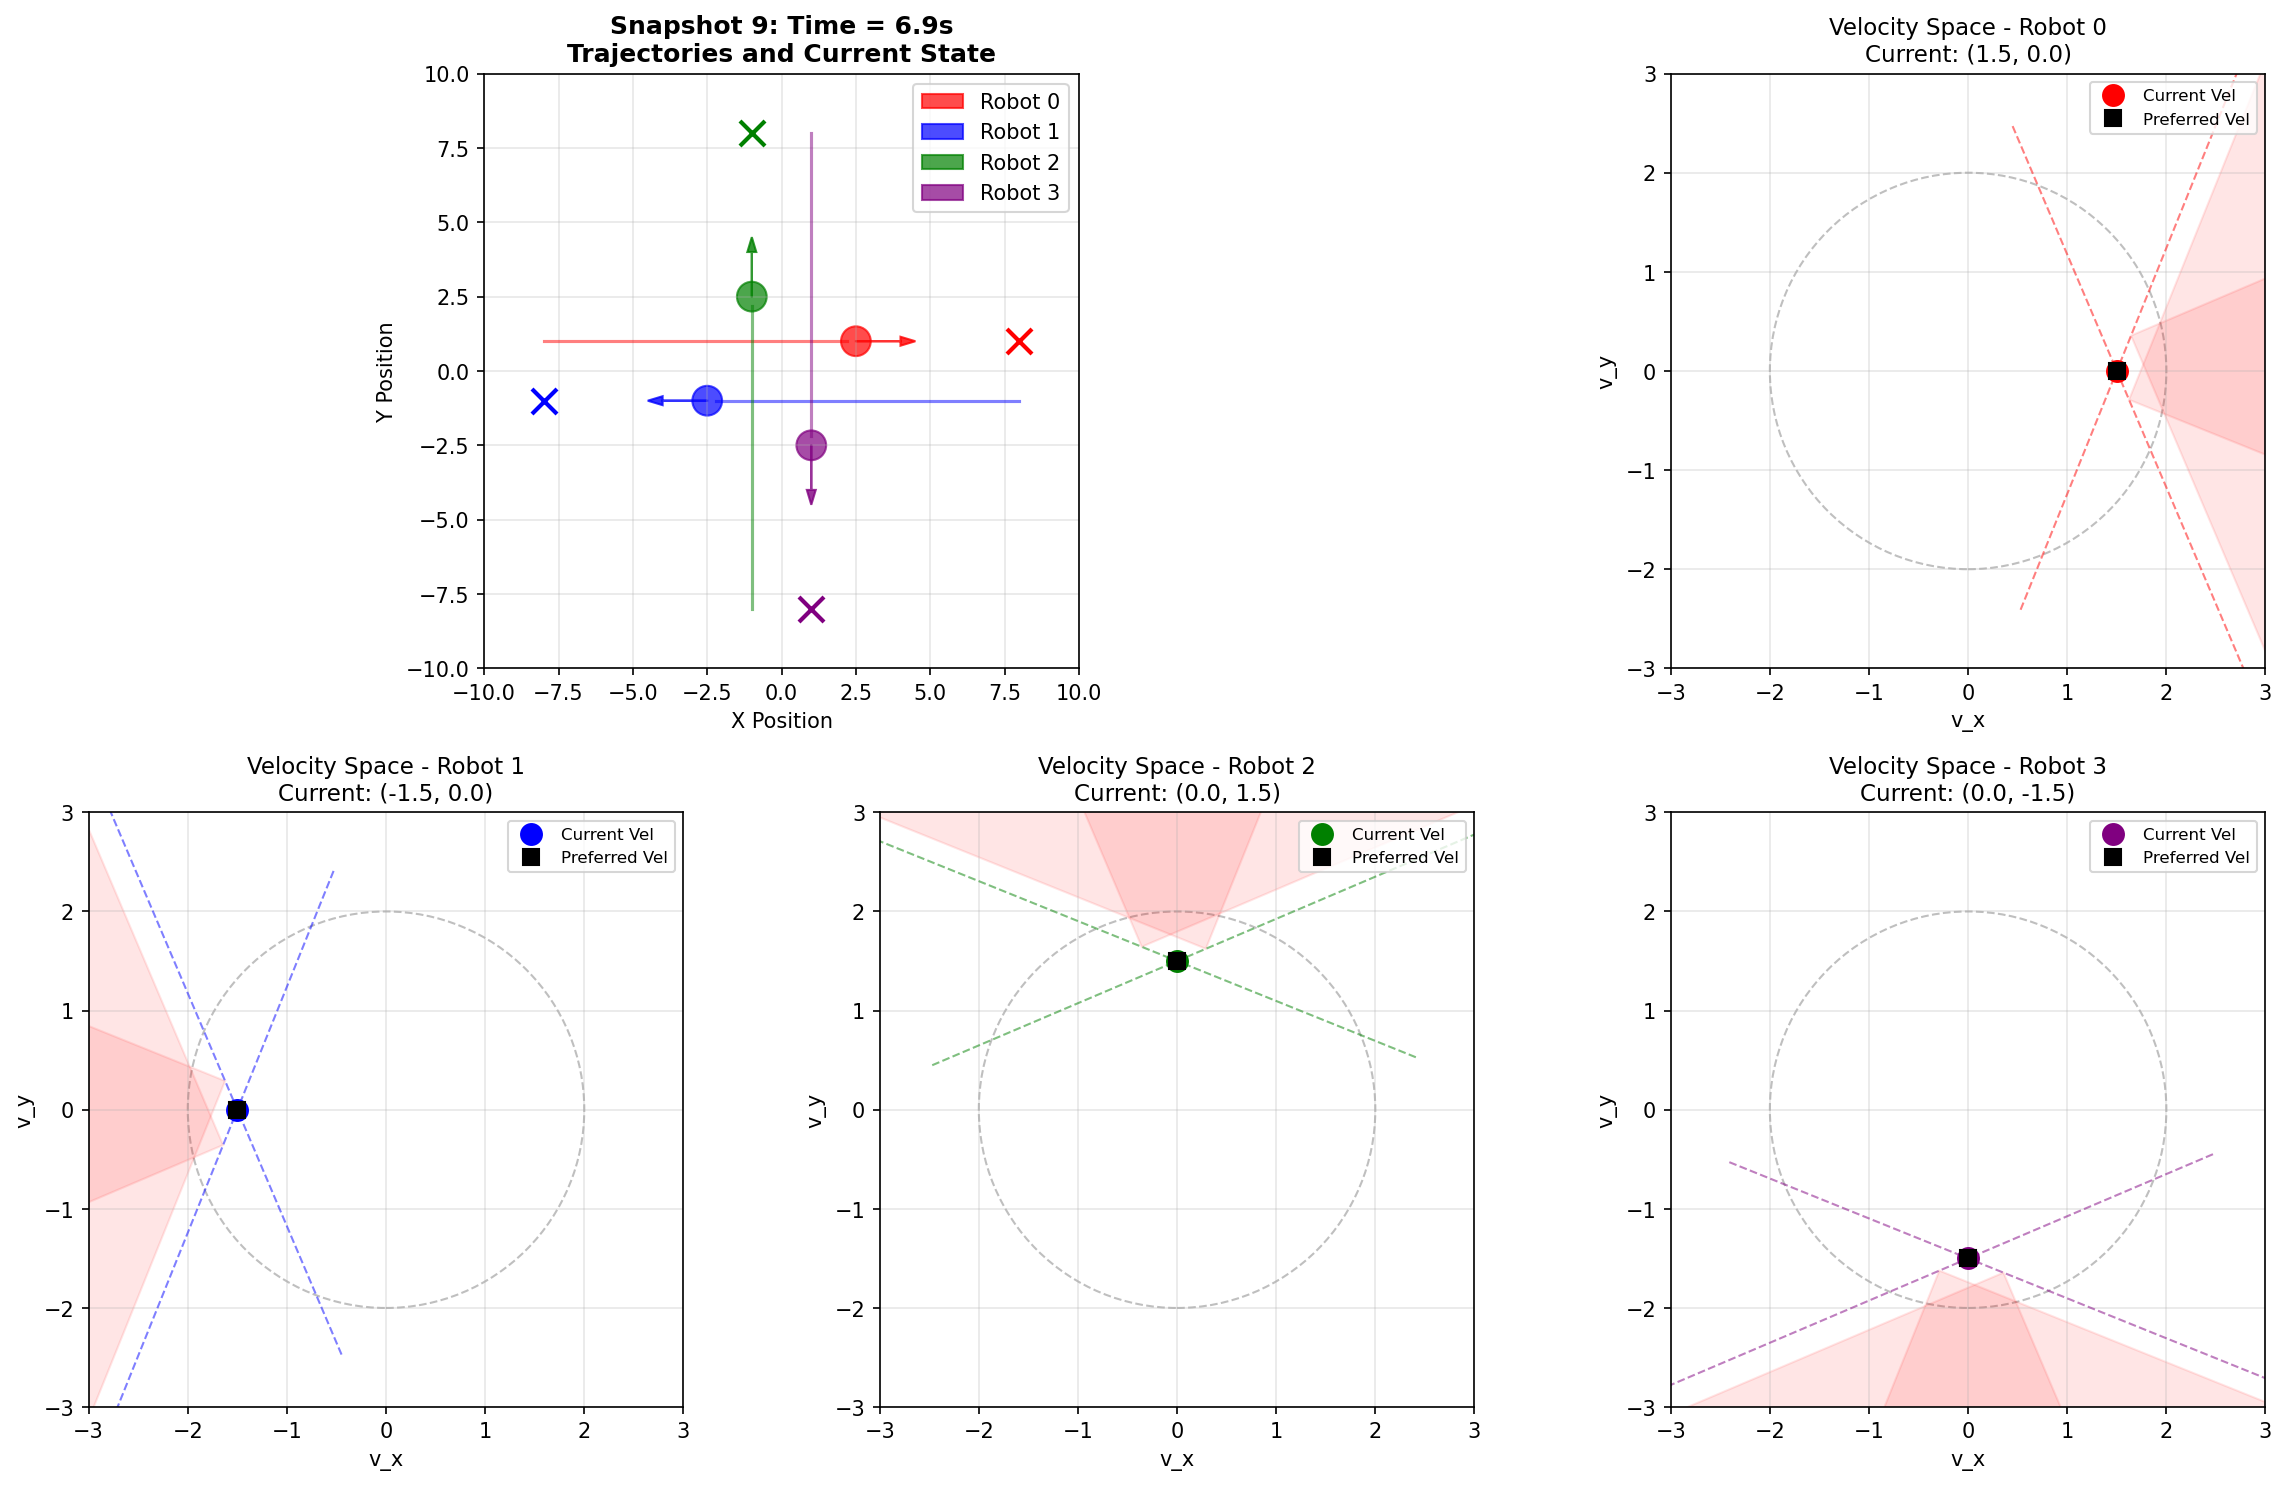

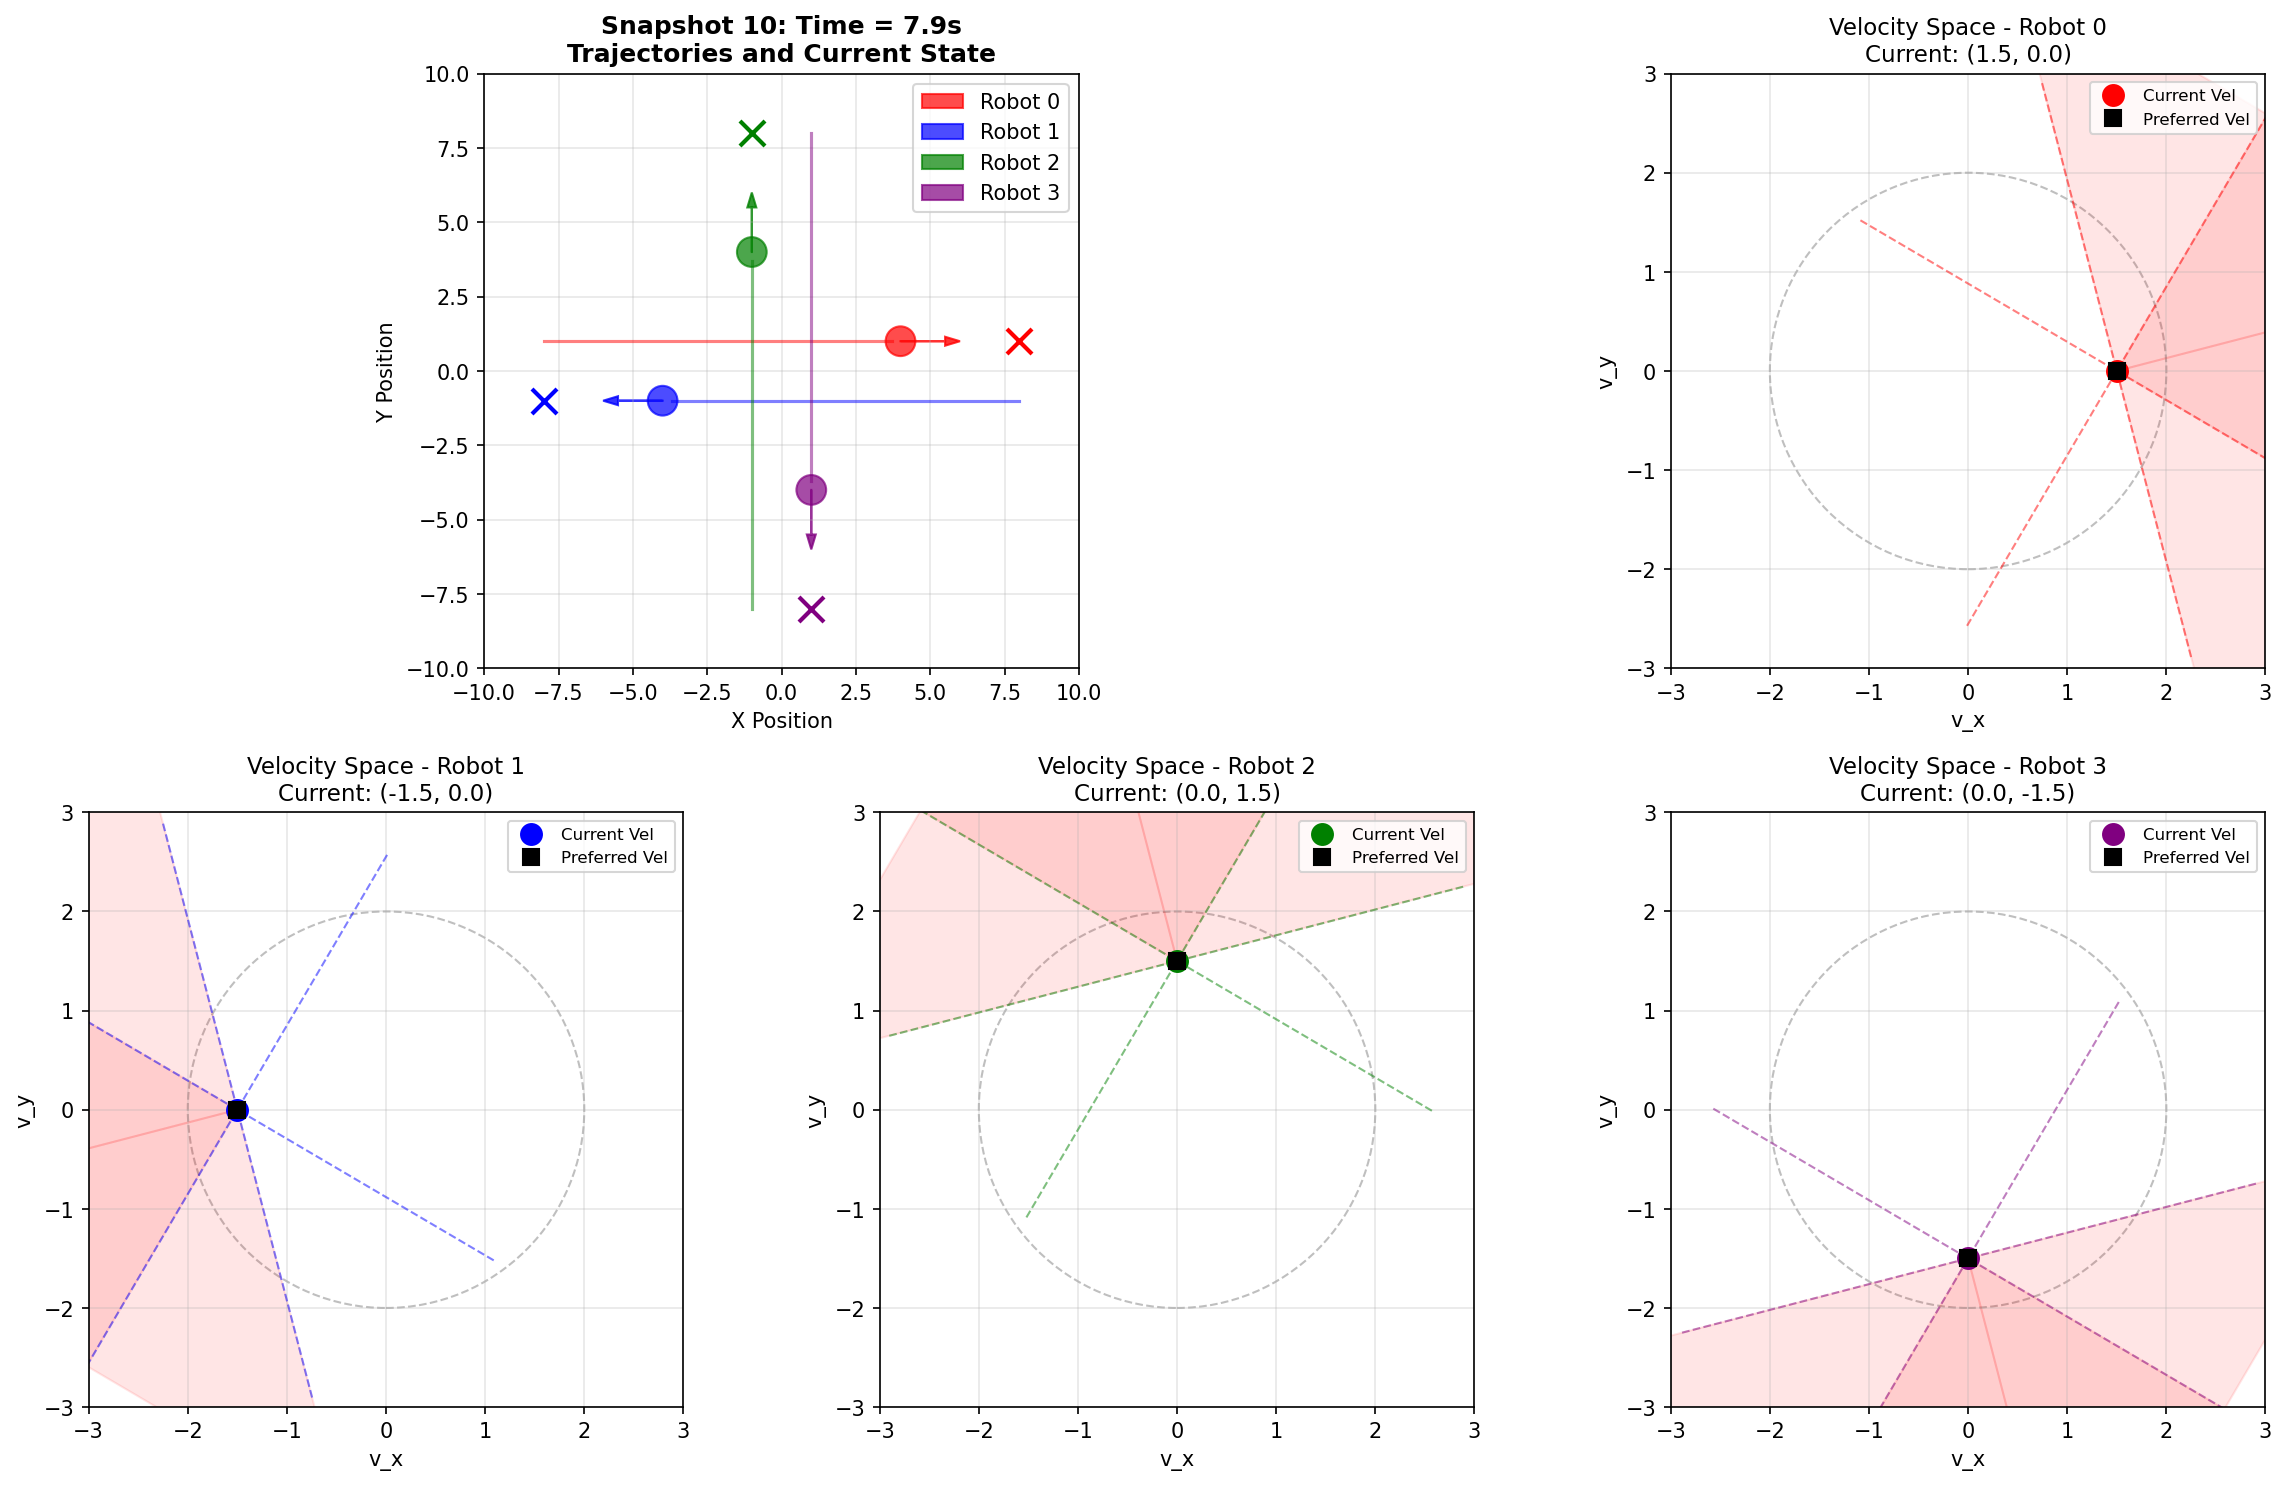

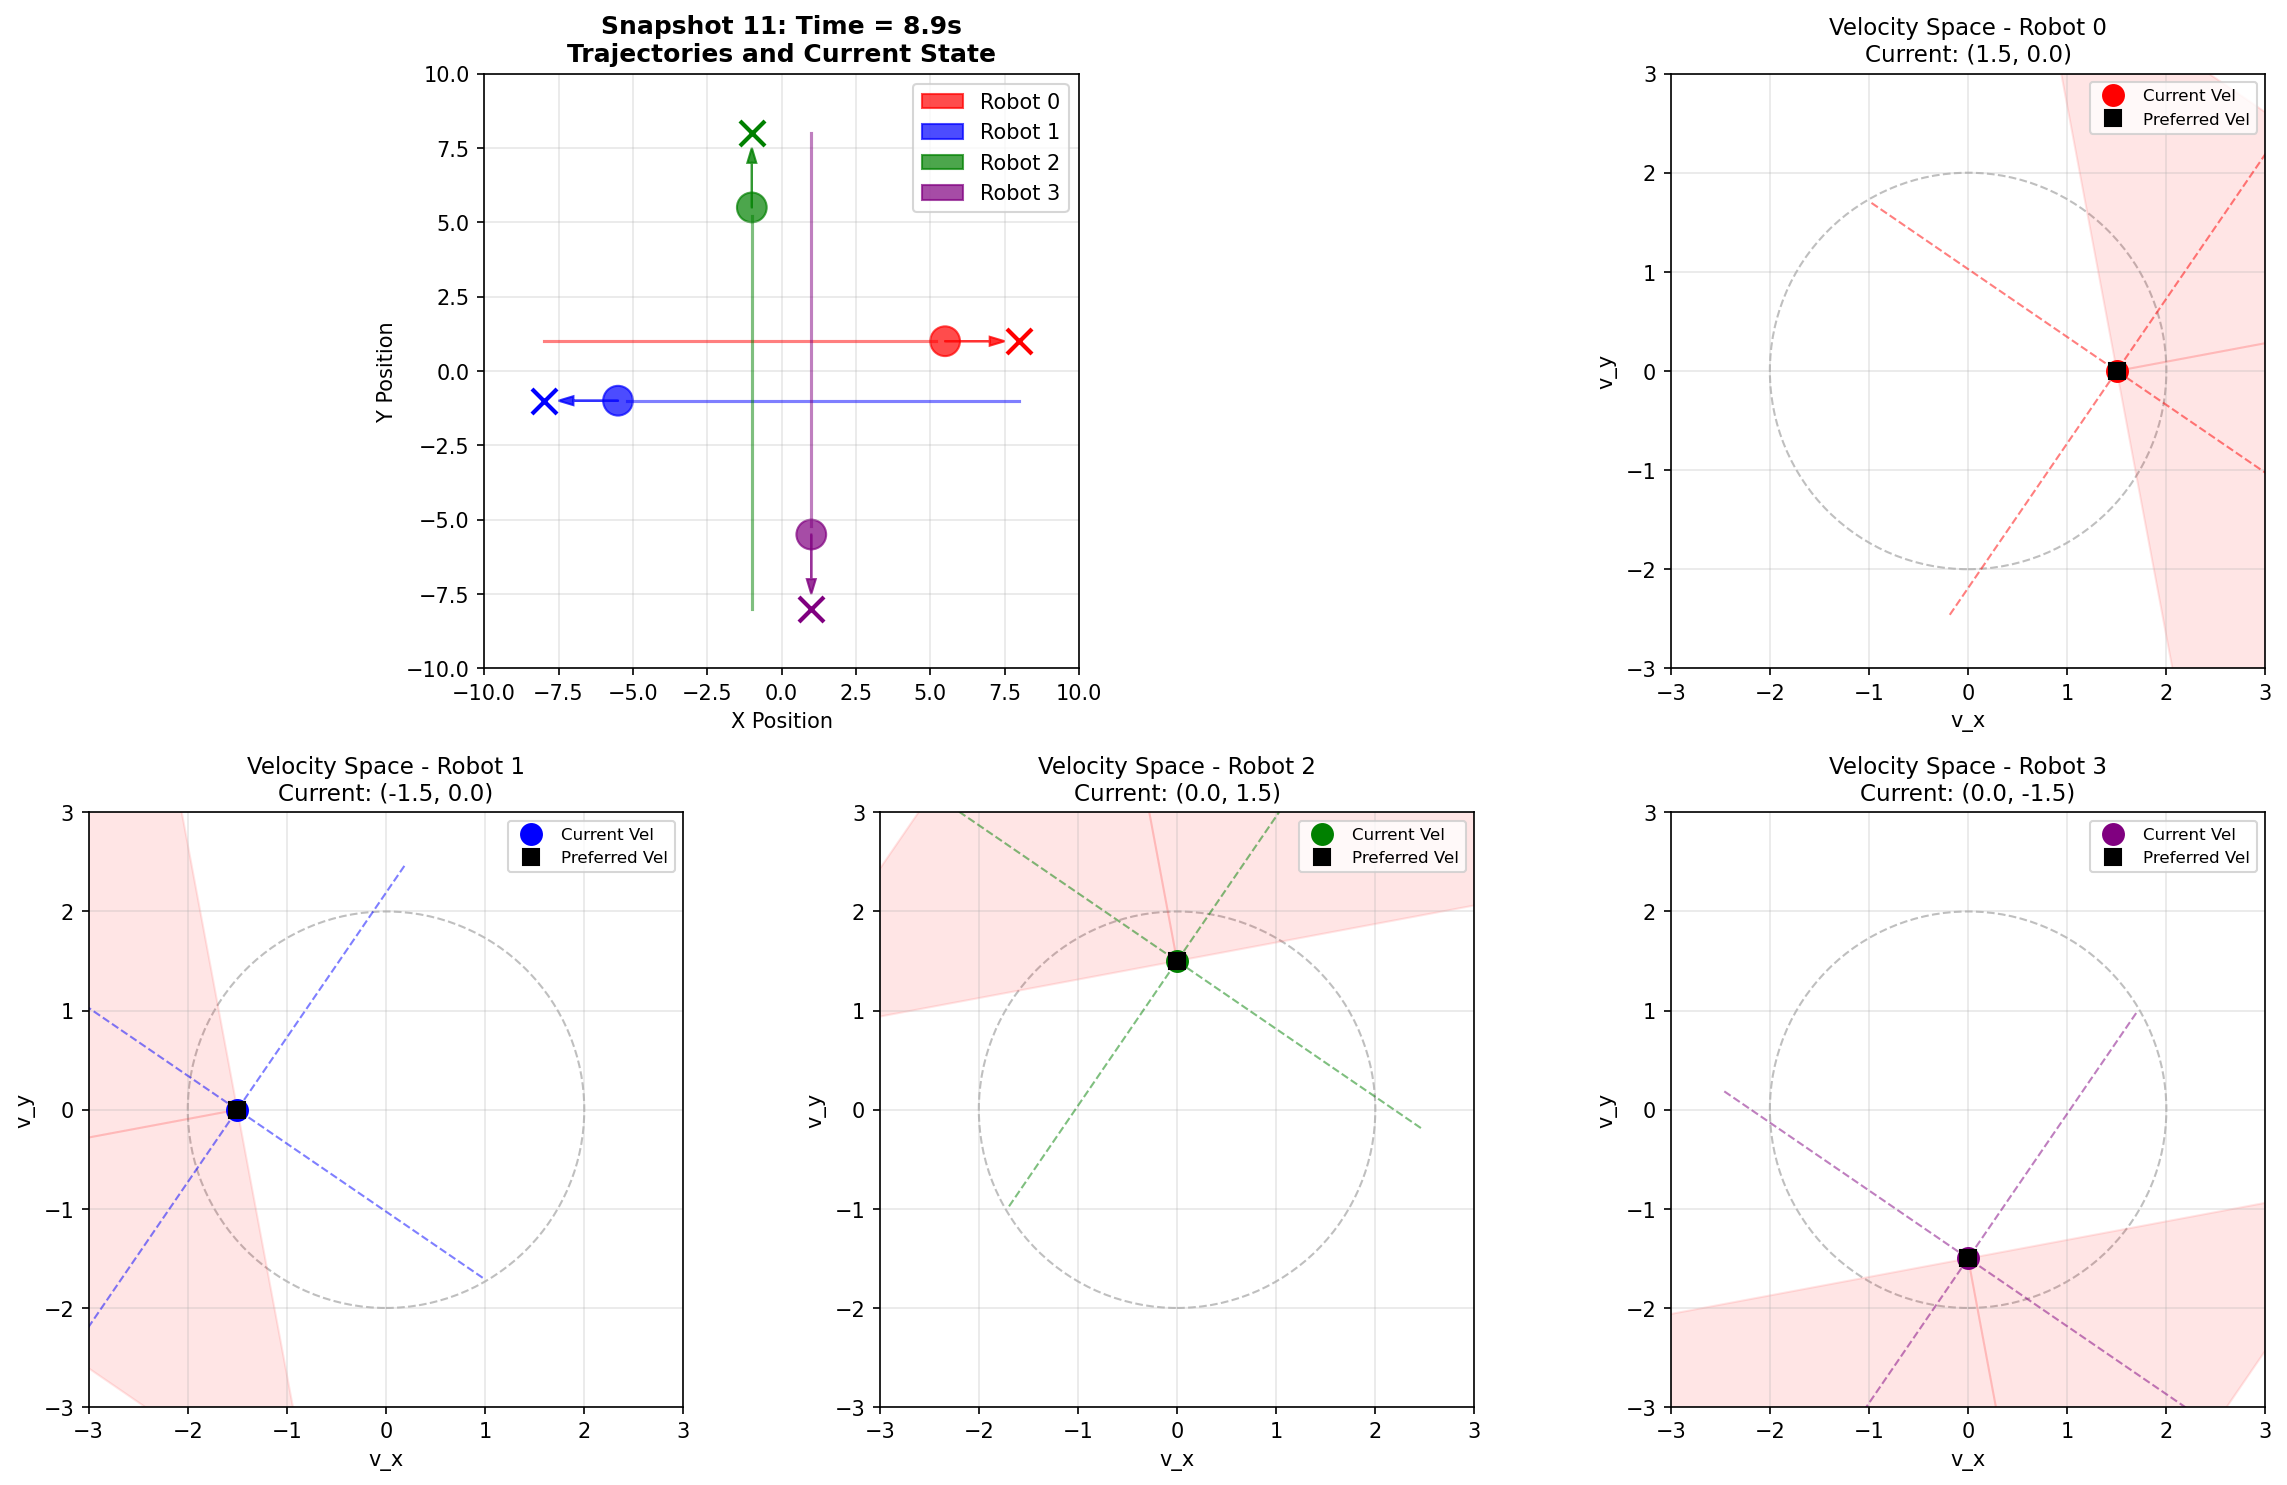

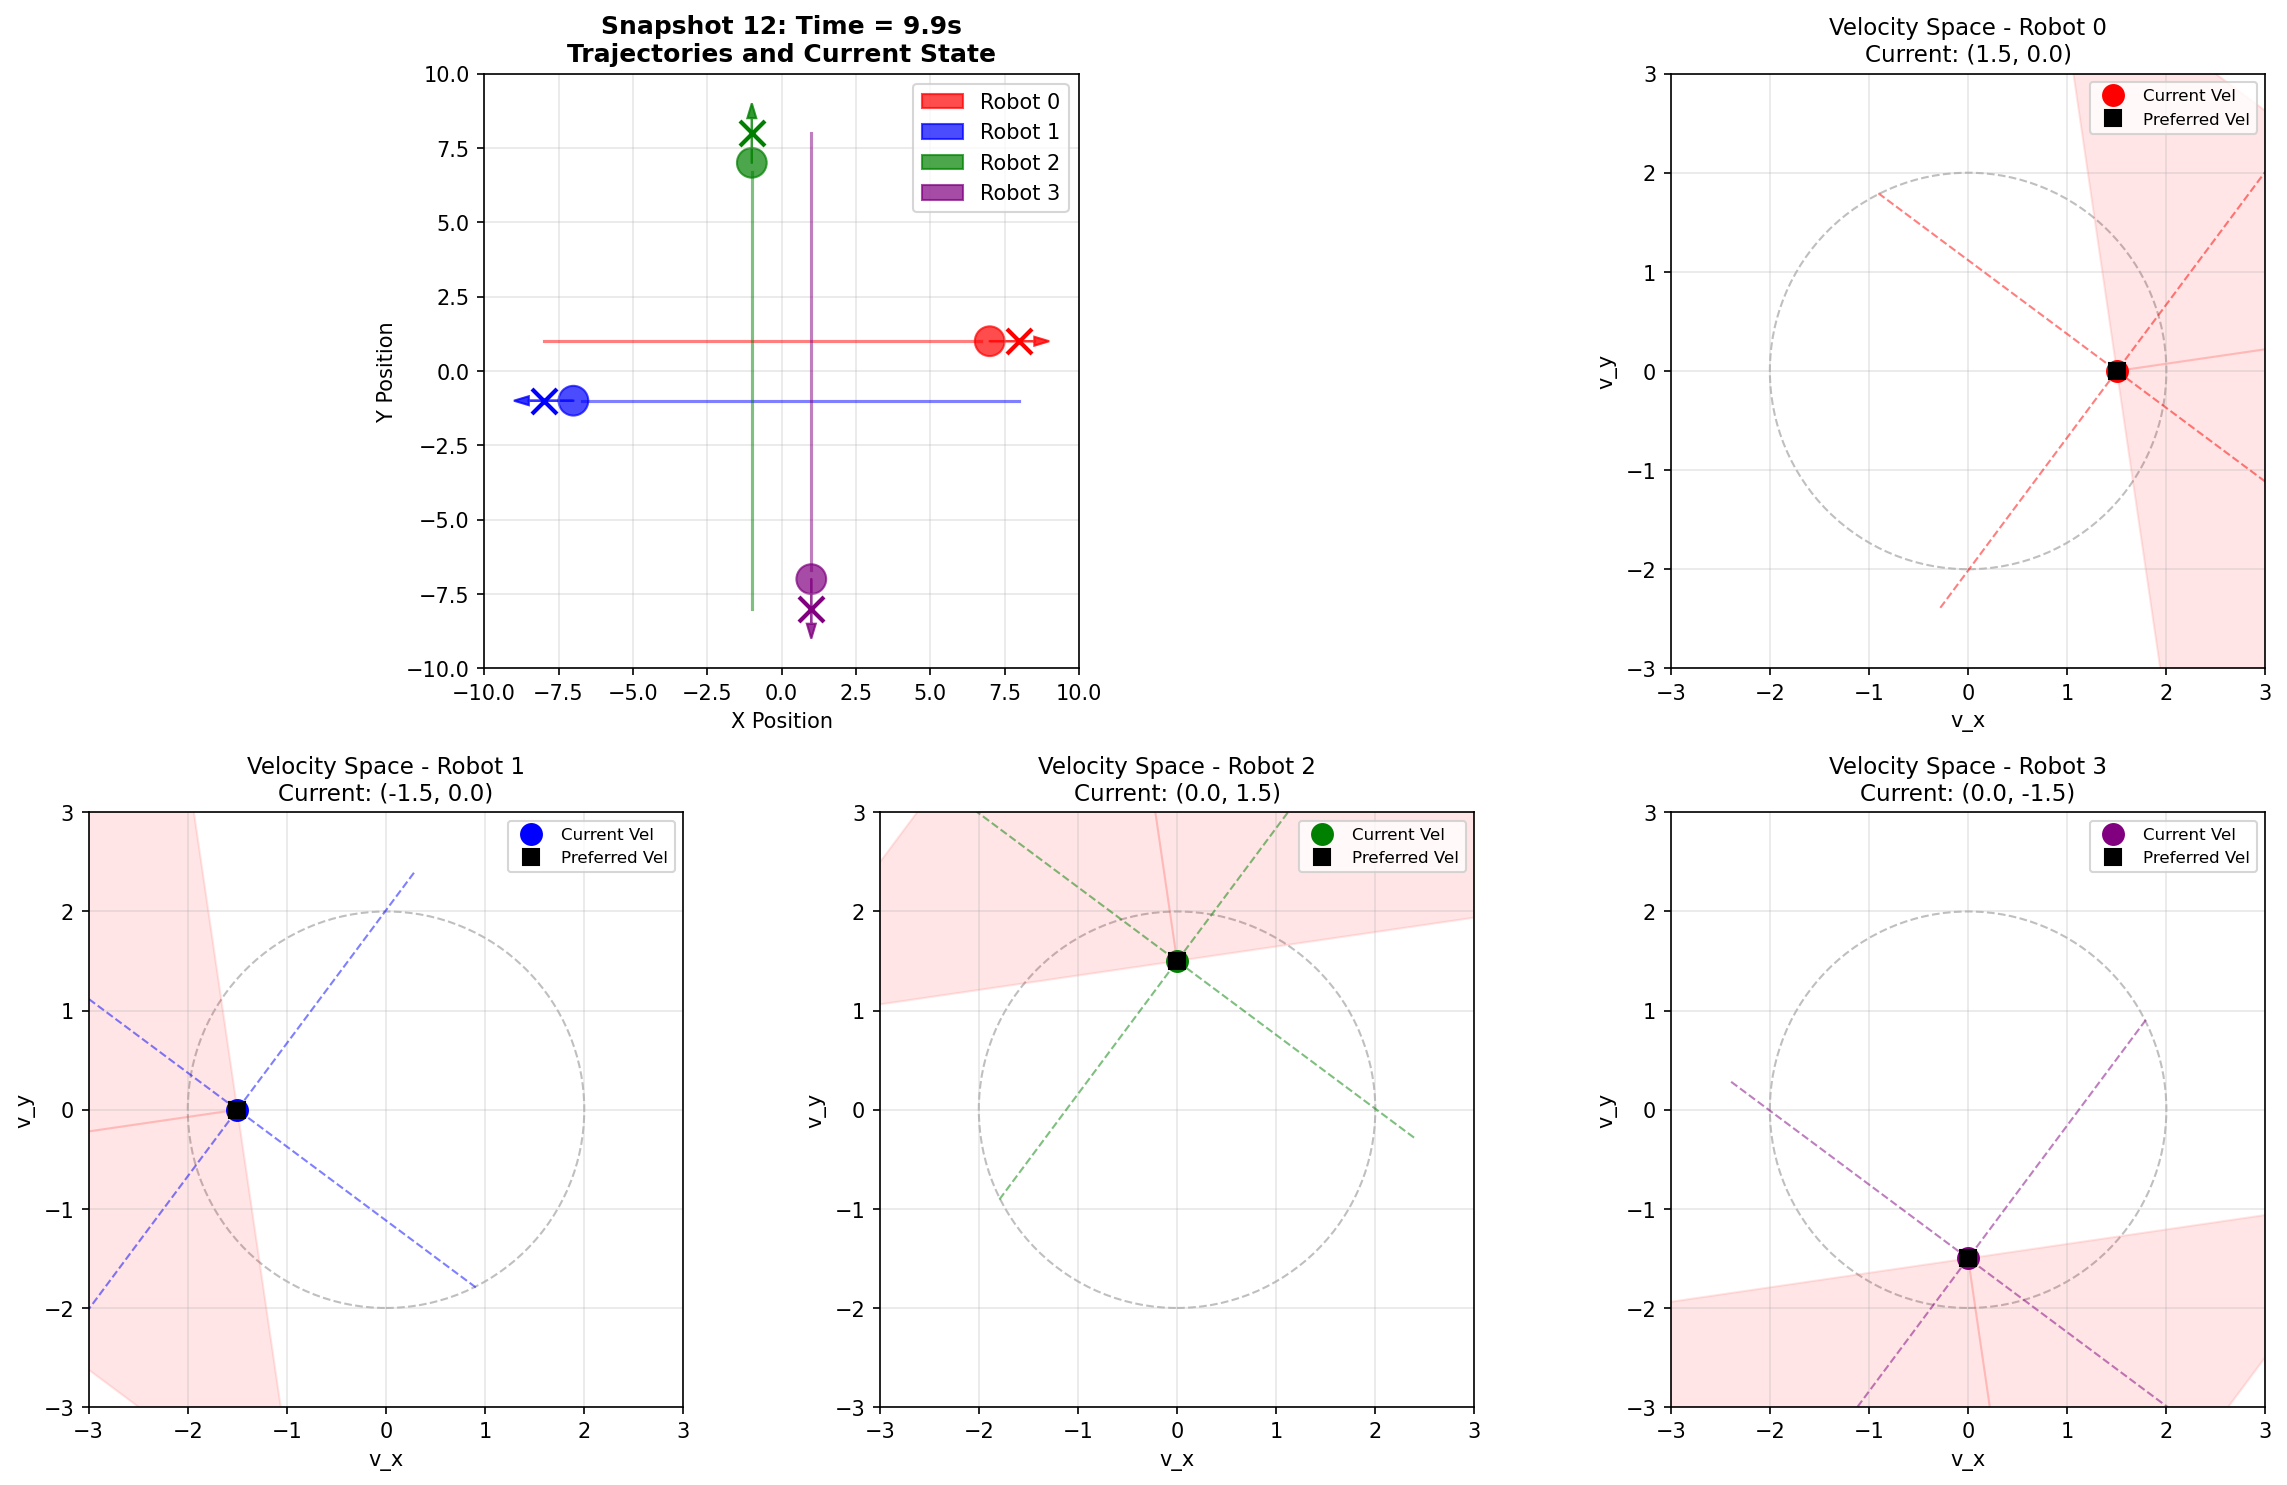

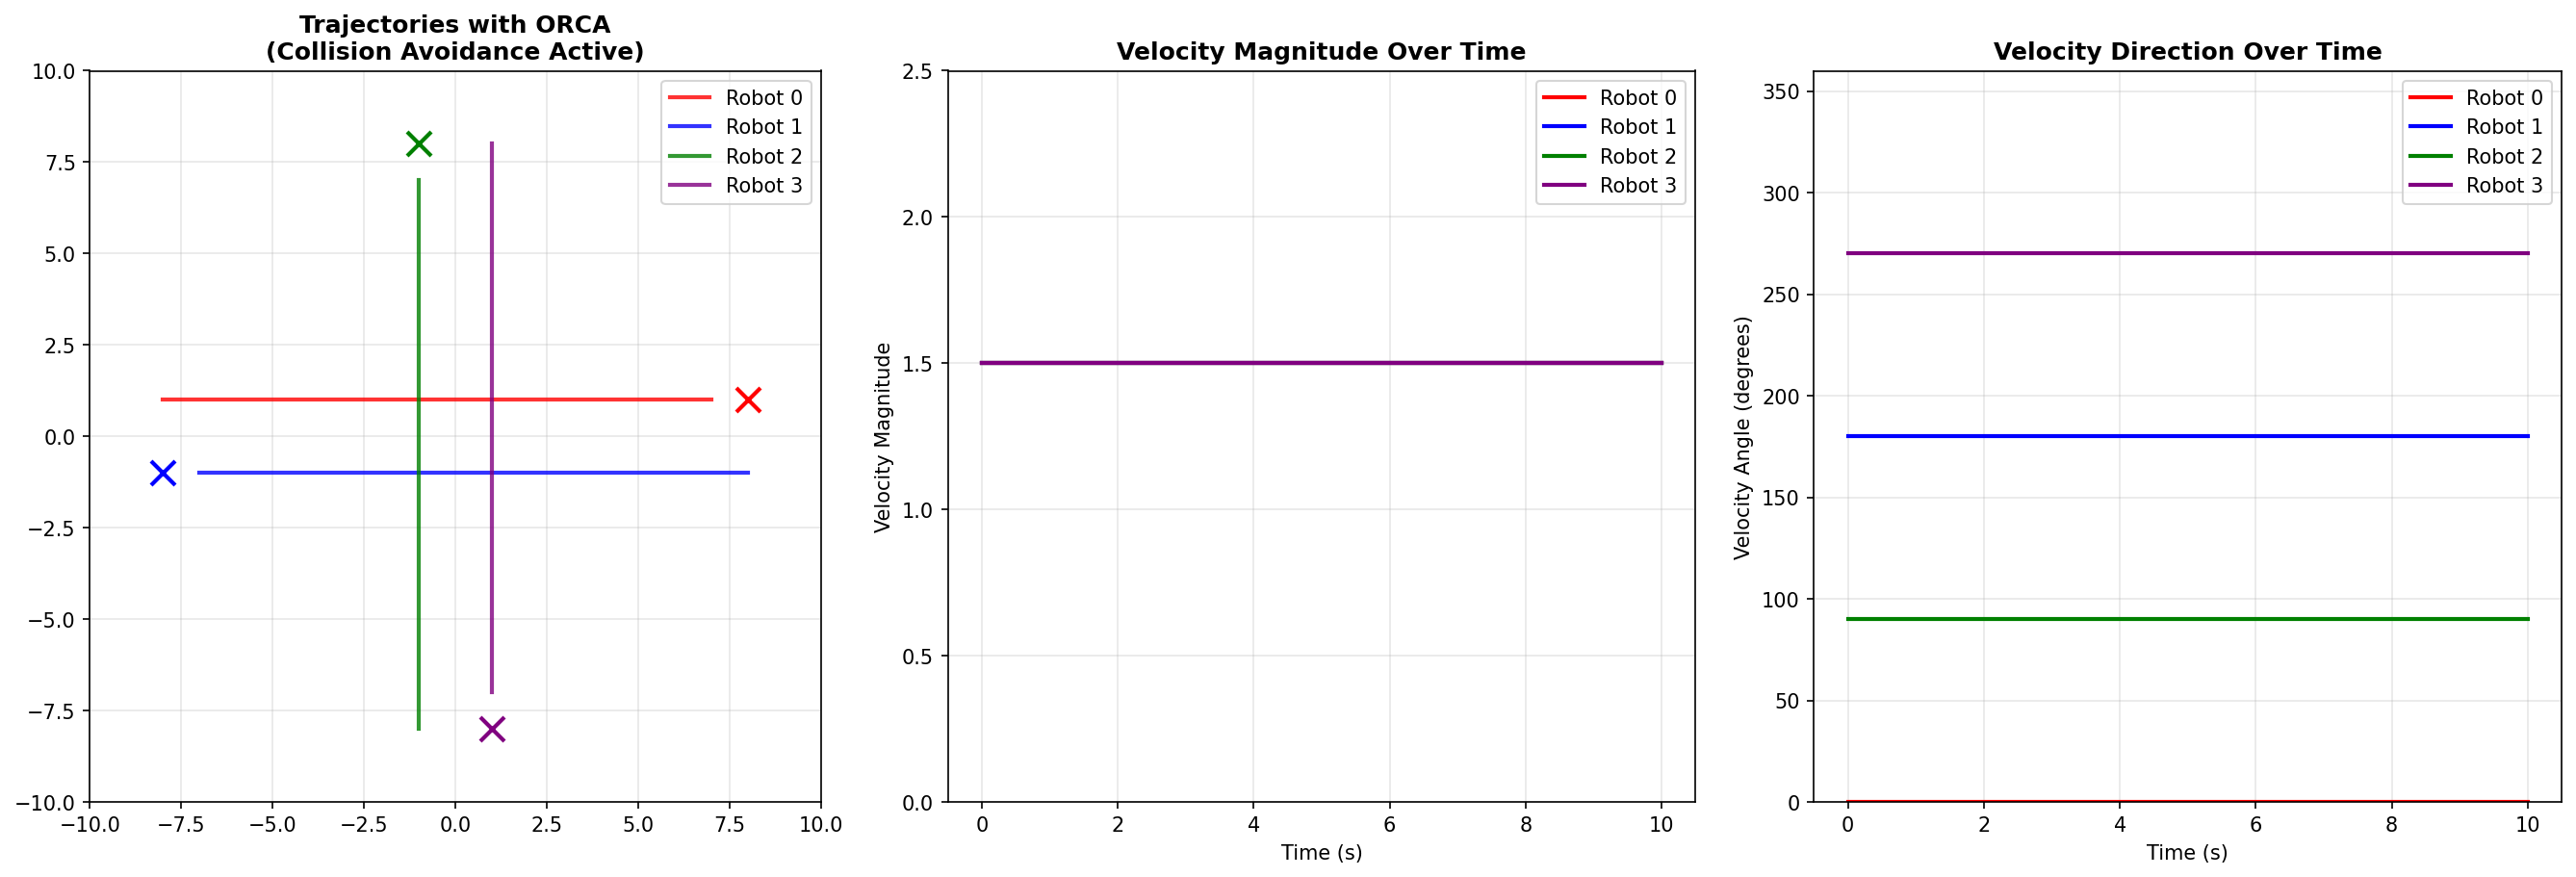

In [2]:
from IPython.display import display, Image, HTML
import os
import re

def display_snapshots_from_folder(folder_path='orca_snapshots'):
    """Reads and displays images sequentially from the specified folder."""

    # 1. Check if the folder exists
    if not os.path.isdir(folder_path):
        print(f"Error: Directory '{folder_path}' not found.")
        print("Please ensure your simulation ran successfully and created this folder.")
        return

    # 2. List all files in the directory
    all_files = os.listdir(folder_path)

    # 3. Filter for PNG files and sort them numerically by snapshot number
    # We use a natural sort to ensure snapshot_01 comes before snapshot_10.
    image_files = [f for f in all_files if f.lower().endswith(('.png'))]

    # Natural sort based on numbers in the filename
    def natural_sort_key(s):
        return [int(text) if text.isdigit() else text.lower()
                for text in re.split(r'(\d+)', s)]

    image_files.sort(key=natural_sort_key)

    if not image_files:
        print(f"No image files found in '{folder_path}'.")
        return

    print(f"--- Displaying {len(image_files)} Snapshots ---")

    # 4. Loop through the sorted list and display each image
    for file_name in image_files:
        file_path = os.path.join(folder_path, file_name)

        # Display the file name as a header
        display(HTML(f'<h3>{file_name.replace(".png", "").replace("_", " ").title()}</h3>'))

        # Display the image inline
        display(Image(filename=file_path))

# Run the function to display your saved simulation results
display_snapshots_from_folder()